# 미니프로젝트: 앙상블 모델링 (Vibe Coding)

#### <목표>
Day 3에서 배운 **Random Forest, GBM, XGBoost, LightGBM, CatBoost**를 Day 2와 **동일한 제조 데이터셋**에 적용해 봅니다.

- Day 1에서의 EDA, 전처리를 복습해보고
- Day 2에서 배웠던 다중선형회귀·Ridge·Lasso·의사결정나무로 만든 결과와 비교하면서
- Day 3에서 배운 앙상블 모델이 단일 모델 대비 어떤 성능 차이를 보이는지 확인해봅니다.

#### <데이터셋 소개>

**1) 회귀용 — Mining Process Flotation Plant (광물 선광 공정 데이터)**
- 철광석을 선광(flotation)하는 공정에서 1시간 간격으로 수집된 실제 산업 데이터
- 공정 변수로 최종 정광의 불순물(실리카) 비율을 예측

| 변수명 | 설명 |
|:---:|:---|
| date | 측정 일시 |
| % Iron Feed, % Silica Feed | 투입 원광의 철/실리카 품위 |
| Starch Flow, Amina Flow | 전분/아민 투입량 (시약) |
| Ore Pulp Flow, pH, Density | 광액 유량/산도/밀도 |
| Flotation Column 01~07 Air Flow | 플로테이션 컬럼별 공기 유량 |
| Flotation Column 01~07 Level | 플로테이션 컬럼별 액위 |
| % Iron Concentrate | 최종 정광의 철 비율 (실험실 측정) |
| **% Silica Concentrate** | **최종 정광의 실리카(불순물) 비율 — 회귀 타겟** |

**2) 분류용 — Steel Plates Faults (철강 표면 결함 검사 데이터)**
- 철강판 표면을 촬영해 측정한 결함의 위치/크기/광도 등으로 결함 유형을 분류하는 실제 품질검사 데이터

| 변수명 | 설명 |
|:---:|:---|
| X/Y_Minimum, X/Y_Maximum | 결함의 위치 범위 |
| Pixels_Areas, X/Y_Perimeter | 결함의 면적·둘레 |
| Sum/Minimum/Maximum_of_Luminosity | 결함 부위의 광도 |
| Length_of_Conveyer, Steel_Plate_Thickness | 설비/소재 정보 |
| TypeOfSteel_A300, TypeOfSteel_A400 | 철강 타입 |
| Edges_Index, Square_Index, Luminosity_Index 등 | 결함 형태 특징 지수 |
| Pastry, Z_Scratch, K_Scatch, Stains, Dirtiness, Bumps, Other_Faults | 결함 유형 |
| **K_Scatch** | **긴 스크래치성 결함 여부 — 분류 타겟** |

#### <실습 태스크>
| 태스크 | 데이터 파일 | 타겟 변수 | 사용 모델 |
|:---:|:---:|:---:|:---|
| 회귀 | `dataset/day2_miniproject_reg.csv` | `% Silica Concentrate` | Random Forest, GBM, XGBoost, LightGBM, CatBoost (회귀) |
| 분류 | `dataset/day2_miniproject_cls.csv` | `K_Scatch` | Random Forest, GBM, XGBoost, LightGBM, CatBoost (분류) |

#### <진행 순서>
**Part A(회귀)** 를 데이터 불러오기 → 탐색 → 전처리 → 모델링 → 예측 → 고도화 → 결과 해석까지 **끝까지 완료한 뒤**, **Part B(분류)** 를 동일한 흐름으로 진행합니다.

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

In [1]:
!pip install xgboost lightgbm catboost

**[과제]** 써니는 Day 2에서 사용한 회귀 및 분류 데이터셋에 다양한 트리 기반 앙상블 모델을 적용해 보려고 합니다. 분석 준비와 데이터 전처리뿐만 아니라, 앙상블 모델 구축 및 하이퍼파라미터 탐색에 필요한 라이브러리를 AI와 상의하여 선정하고 불러오는 코드를 작성해 보세요.

In [30]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 분할 · 하이퍼파라미터 탐색
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit

# 전처리 (Day 2와 동일 데이터셋, 스케일링 검토용)
from sklearn.preprocessing import StandardScaler

# 트리 기반 앙상블 모델 — 회귀
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# 트리 기반 앙상블 모델 — 분류
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# 평가 지표 — 회귀
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
)

# 평가 지표 — 분류
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

warnings.filterwarnings('ignore')

---
# Part A. 회귀 태스크 — Mining Process Flotation Plant

## A-0) 데이터 불러오기

**[과제]** 써니는 Day 2에서 사용했던 `dataset/day2_miniproject_reg.csv` 파일을 그대로 불러오려고 합니다. 적절한 변수명으로 데이터프레임을 만들어 보세요.

In [3]:
# 회귀용 데이터 불러오기 (Mining Process Flotation Plant)
df_reg = pd.read_csv('dataset/day2_miniproject_reg.csv')

print("데이터 크기 :", df_reg.shape)
df_reg.head()

데이터 크기 : (3948, 24)


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,3/29/2017 12:00,60.18,9.34,1060.859297,379.836203,400.982539,9.527187,1.550374,200.035839,195.577700,...,249.992956,753.724247,726.559437,860.557818,477.349197,452.512522,478.219647,470.105547,66.44,1.36
1,3/29/2017 13:00,60.18,9.34,2034.926525,322.233975,400.468947,9.700679,1.532017,199.990122,195.106250,...,250.059711,848.675503,777.784437,869.419421,483.816131,469.448172,471.607075,462.665478,66.57,1.43
2,3/29/2017 14:00,60.18,9.34,1435.425811,474.656322,399.157083,9.687788,1.645200,200.019311,195.604928,...,250.111328,851.951492,776.293654,879.704989,456.147231,453.227000,447.708467,453.475667,66.64,1.33
3,3/29/2017 15:00,60.18,9.34,618.460387,396.377733,398.942522,9.851689,1.559929,199.940833,195.657094,...,250.028506,855.910630,780.369869,882.093896,449.410744,448.581506,450.697578,448.660094,66.41,1.27
4,3/29/2017 16:00,59.54,9.56,1367.502858,317.134072,400.836283,9.936163,1.530984,199.878922,196.162864,...,250.122067,851.603513,784.446084,884.840698,450.123050,451.774694,451.574422,449.406894,63.63,5.50


---
## A-1) 데이터 탐색 (EDA)

### A-1-1) Value 기반 탐색

**[과제]** 써니는 오늘도 모델링에 앞서 데이터 상태를 다시 한번 점검하고 싶습니다. AI와 함께 데이터 구조, 결측치, 수집 기간 등 기본적인 특성을 다시 확인해 보세요.

In [4]:
# ============================================================
# ① 데이터 크기 확인
# ============================================================
# shape → (행 개수, 열 개수) 튜플
# 이 데이터: 1시간 간격 공정 데이터이므로 행 ≈ 측정 시점 수
print("=" * 50)
print("1. 데이터 크기")
print("=" * 50)
print("데이터 크기 :", df_reg.shape)
print(f"  → {df_reg.shape[0]:,}개 시점, {df_reg.shape[1]}개 변수")

1. 데이터 크기
데이터 크기 : (3948, 24)
  → 3,948개 시점, 24개 변수


In [5]:
# ============================================================
# ② 상위 5행 미리보기
# ============================================================
# head(n): 앞에서 n행만 출력 (기본 n=5)
# 각 공정 변수의 실제 숫자 범위를 눈으로 확인
print("=" * 50)
print("2. 데이터 미리보기")
print("=" * 50)
df_reg.head()

2. 데이터 미리보기


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,3/29/2017 12:00,60.18,9.34,1060.859297,379.836203,400.982539,9.527187,1.550374,200.035839,195.577700,...,249.992956,753.724247,726.559437,860.557818,477.349197,452.512522,478.219647,470.105547,66.44,1.36
1,3/29/2017 13:00,60.18,9.34,2034.926525,322.233975,400.468947,9.700679,1.532017,199.990122,195.106250,...,250.059711,848.675503,777.784437,869.419421,483.816131,469.448172,471.607075,462.665478,66.57,1.43
2,3/29/2017 14:00,60.18,9.34,1435.425811,474.656322,399.157083,9.687788,1.645200,200.019311,195.604928,...,250.111328,851.951492,776.293654,879.704989,456.147231,453.227000,447.708467,453.475667,66.64,1.33
3,3/29/2017 15:00,60.18,9.34,618.460387,396.377733,398.942522,9.851689,1.559929,199.940833,195.657094,...,250.028506,855.910630,780.369869,882.093896,449.410744,448.581506,450.697578,448.660094,66.41,1.27
4,3/29/2017 16:00,59.54,9.56,1367.502858,317.134072,400.836283,9.936163,1.530984,199.878922,196.162864,...,250.122067,851.603513,784.446084,884.840698,450.123050,451.774694,451.574422,449.406894,63.63,5.50


In [6]:
# ============================================================
# ③ 컬럼명 · 자료형 확인
# ============================================================
print("=" * 50)
print("3. 컬럼명 목록")
print("=" * 50)
print(list(df_reg.columns))
print(f"총 {len(df_reg.columns)}개 변수")

print("\n" + "=" * 50)
print("4. 자료형 요약")
print("=" * 50)
# info(): 각 컬럼의 Non-Null 개수, dtype, 메모리 사용량
df_reg.info()

3. 컬럼명 목록
['date', '% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow', 'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density', 'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow', 'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow', 'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow', 'Flotation Column 07 Air Flow', 'Flotation Column 01 Level', 'Flotation Column 02 Level', 'Flotation Column 03 Level', 'Flotation Column 04 Level', 'Flotation Column 05 Level', 'Flotation Column 06 Level', 'Flotation Column 07 Level', '% Iron Concentrate', '% Silica Concentrate']
총 24개 변수

4. 자료형 요약
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3948 entries, 0 to 3947
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   date                          3948 non-null   object 
 1   % Iron Feed                   3948 non-null   float64
 2   % Silica Feed              

In [7]:
# ============================================================
# ④ 기술통계량 (수치형 변수만)
# ============================================================
# describe(): count, mean, std, min, 25%, 50%, 75%, max
# 기본값은 수치형(float64)만 계산 → date(object)는 제외됨
print("=" * 50)
print("5. 기술통계량")
print("=" * 50)
df_reg.describe().T   # .T: 변수를 행으로 → 읽기 쉬움

5. 기술통계량


,count,mean,std,min,25%,50%,75%,max
% Iron Feed,3948.0,56.220301,5.231150,42.740000,52.610000,55.940000,59.720000,65.780000
% Silica Feed,3948.0,14.767789,6.887711,1.310000,8.812500,14.200000,20.140000,33.400000
Starch Flow,3948.0,2847.012956,948.913479,54.595483,2146.232398,2880.359057,3514.789671,6270.158798
Amina Flow,3948.0,488.720690,83.769854,242.927477,436.428747,502.685958,550.144572,736.982378
Ore Pulp Flow,3948.0,397.471417,8.491449,376.837604,398.774394,399.835435,400.592916,418.070232
Ore Pulp pH,3948.0,9.769643,0.378012,8.753389,9.542790,9.796511,10.033416,10.807370
Ore Pulp Density,3948.0,1.679042,0.063417,1.519926,1.649868,1.694900,1.719869,1.818191
Flotation Column 01 Air Flow,3948.0,281.287417,29.361843,175.885579,250.109688,299.850578,299.955660,312.295415
Flotation Column 02 Air Flow,3948.0,278.182019,29.490104,178.188430,250.119040,299.596767,299.991808,309.887767
Flotation Column 03 Air Flow,3948.0,282.253076,28.244196,177.202665,250.109164,299.893233,299.948658,302.783000


In [8]:
# ============================================================
# ⑤ 결측치 확인
# ============================================================
# isnull(): 결측이면 True
# .sum(): 변수별 결측 개수 합계
print("=" * 50)
print("6. 결측치")
print("=" * 50)
missing = df_reg.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "결측치 없음 ✓")
print("총 결측치 개수 :", missing.sum())

6. 결측치
결측치 없음 ✓
총 결측치 개수 : 0


In [9]:
# ============================================================
# ⑥ 중복 행 확인
# ============================================================
# duplicated(): 이전 행과 완전히 동일하면 True
print("=" * 50)
print("7. 중복 행")
print("=" * 50)
print("중복 행 개수 :", df_reg.duplicated().sum())

7. 중복 행
중복 행 개수 : 0


In [10]:
# ============================================================
# ⑦ 수집 기간 확인 (시계열 EDA의 핵심!)
# ============================================================
# date는 현재 문자열(object) → datetime으로 변환 후 min/max
print("=" * 50)
print("8. 수집 기간")
print("=" * 50)

df_reg['date'] = pd.to_datetime(df_reg['date'])  # 문자열 → 날짜형
print("시작 :", df_reg['date'].min())
print("종료 :", df_reg['date'].max())
print("기간 :", (df_reg['date'].max() - df_reg['date'].min()).days, "일")

# 시간 순 정렬 여부 (시계열 분할 전에 중요)
is_sorted = df_reg['date'].is_monotonic_increasing
print("시간 순 정렬 여부 :", "정렬됨 ✓" if is_sorted else "정렬 필요!")

8. 수집 기간
시작 : 2017-03-29 12:00:00
종료 : 2017-09-09 23:00:00
기간 : 164 일
시간 순 정렬 여부 : 정렬됨 ✓


In [11]:
# ============================================================
# ⑧ 타겟 변수 집중 확인
# ============================================================
# 회귀 타겟: % Silica Concentrate (정광 실리카 불순물 비율)
target = '% Silica Concentrate'

print("=" * 50)
print(f"9. 타겟 변수 [{target}]")
print("=" * 50)
print(df_reg[target].describe())

print(f"\n타겟 평균 : {df_reg[target].mean():.3f}%")
print(f"타겟 표준편차 : {df_reg[target].std():.3f}")
print(f"타겟 범위 : {df_reg[target].min():.2f} ~ {df_reg[target].max():.2f}")

9. 타겟 변수 [% Silica Concentrate]
count    3948.000000
mean        2.322261
std         1.120117
min         0.600000
25%         1.440000
50%         2.000000
75%         2.992500
max         5.530000
Name: % Silica Concentrate, dtype: float64

타겟 평균 : 2.322%
타겟 표준편차 : 1.120
타겟 범위 : 0.60 ~ 5.53


In [12]:
# ============================================================
# ⑨ 전처리 시 주의할 변수 미리 체크
# ============================================================
# Day 2에서 확인한 내용 — 앙상블 모델링 전에 다시 점검
print("=" * 50)
print("10. 모델링 전 참고 사항")
print("=" * 50)

# % Iron Concentrate ↔ % Silica Concentrate 상관이 높음 (누수 가능성)
iron_col = '% Iron Concentrate'
corr_target = df_reg[[iron_col, target]].corr().iloc[0, 1]
print(f"{iron_col} vs {target} 상관계수 : {corr_target:.3f}")
print("  → 전처리 단계에서 제거 여부를 검토할 예정 (데이터 누수 방지)")

print(f"\ndate 컬럼 : 입력 변수로 쓰지 않음 (시간 식별자)")
print(f"수치형 변수 개수 : {df_reg.select_dtypes(include='number').shape[1]}개")

10. 모델링 전 참고 사항
% Iron Concentrate vs % Silica Concentrate 상관계수 : -0.803
  → 전처리 단계에서 제거 여부를 검토할 예정 (데이터 누수 방지)

date 컬럼 : 입력 변수로 쓰지 않음 (시간 식별자)
수치형 변수 개수 : 23개


### A-1-2) Graph 기반 탐색

**[과제]** 써니는 오늘도 어제처럼 시계열 변화 패턴과 변수 간 상관관계를 앙상블 모델링 전에 다시 시각화로 점검하려고 합니다. AI와 함께 시간 흐름에 따른 변수 변화를 시각화해 보세요.

In [13]:
# ============================================================
# 시계열 시각화 준비
# ============================================================

# 시간순 정렬 — 시계열 그래프의 필수 단계
df_ts = df_reg.sort_values('date').reset_index(drop=True)

# 수치형 변수만 추출 (date는 object/datetime이라 제외됨)
num_cols = df_ts.select_dtypes(include='number').columns.tolist()
print("시각화 변수 개수 :", len(num_cols))   # 23개
print("수집 기간 :", df_ts['date'].min(), "~", df_ts['date'].max())

시각화 변수 개수 : 23
수집 기간 : 2017-03-29 12:00:00 ~ 2017-09-09 23:00:00


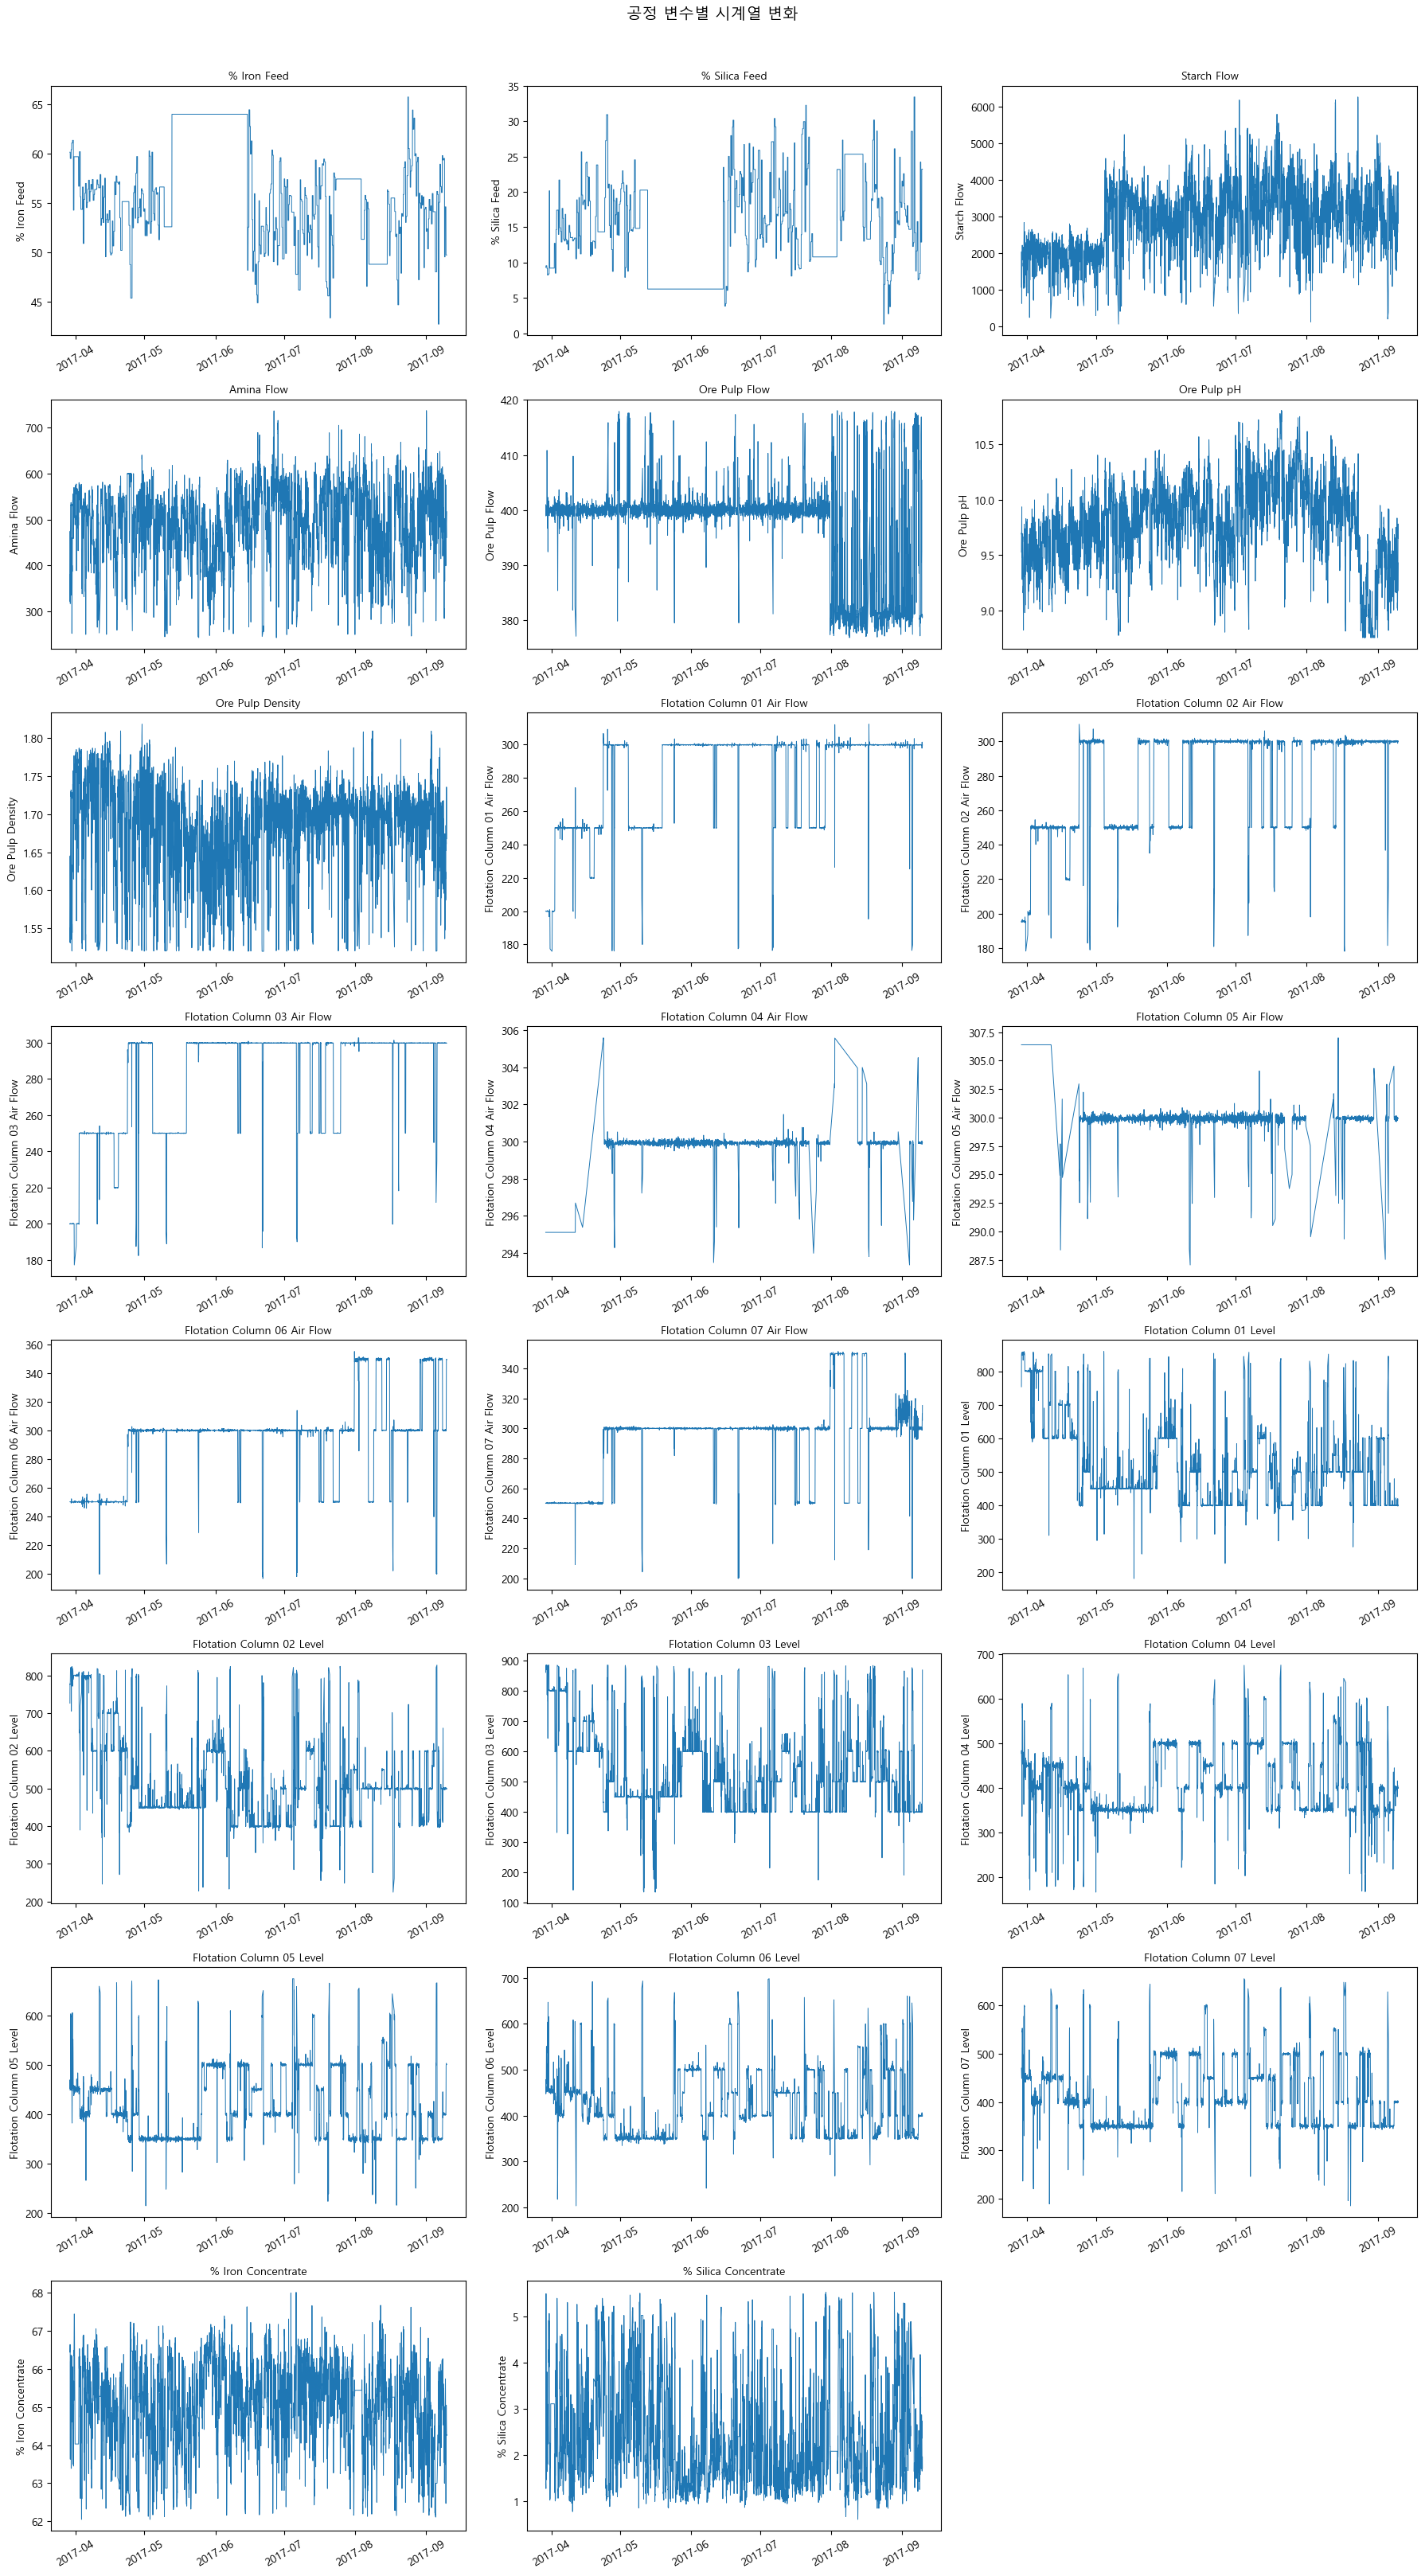

In [14]:
# ============================================================
# 변수별 시계열 변화 (date × 각 수치형 변수)
# ============================================================
n_cols = 3                                          # 한 행에 3개 그래프
n_rows = int(np.ceil(len(num_cols) / n_cols))       # 필요한 행 수 자동 계산

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()                               # 2차원 배열 → 1차원 (반복문 편의)

for i, col in enumerate(num_cols):
    # sns.lineplot: x=시간, y=변수값으로 꺾은선 그래프
    sns.lineplot(data=df_ts, x='date', y=col, ax=axes[i], linewidth=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')                          # x축 라벨 중복 방지
    axes[i].tick_params(axis='x', rotation=30)      # 날짜 라벨 기울이기

# 변수 수보다 subplot이 많으면 빈 칸 제거
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('공정 변수별 시계열 변화', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**[과제]** 써니는 변수들 간에 강하게 얽혀 있는 관계(다중공선성 후보)가 있는지 한눈에 살펴보고 싶습니다. AI와 상의해서 상관관계 히트맵을 그려보고 트리 기반 앙상블 모델에서는 이 다중공선성이 Day 2의 선형 모델만큼 문제가 되는지도 함께 생각해 보세요.

In [16]:
# 수치형만 선택 → 피어슨 상관계수 행렬 (23×23)
corr = df_ts.select_dtypes(include='number').corr()
corr.shape   # (23, 23)

(23, 23)

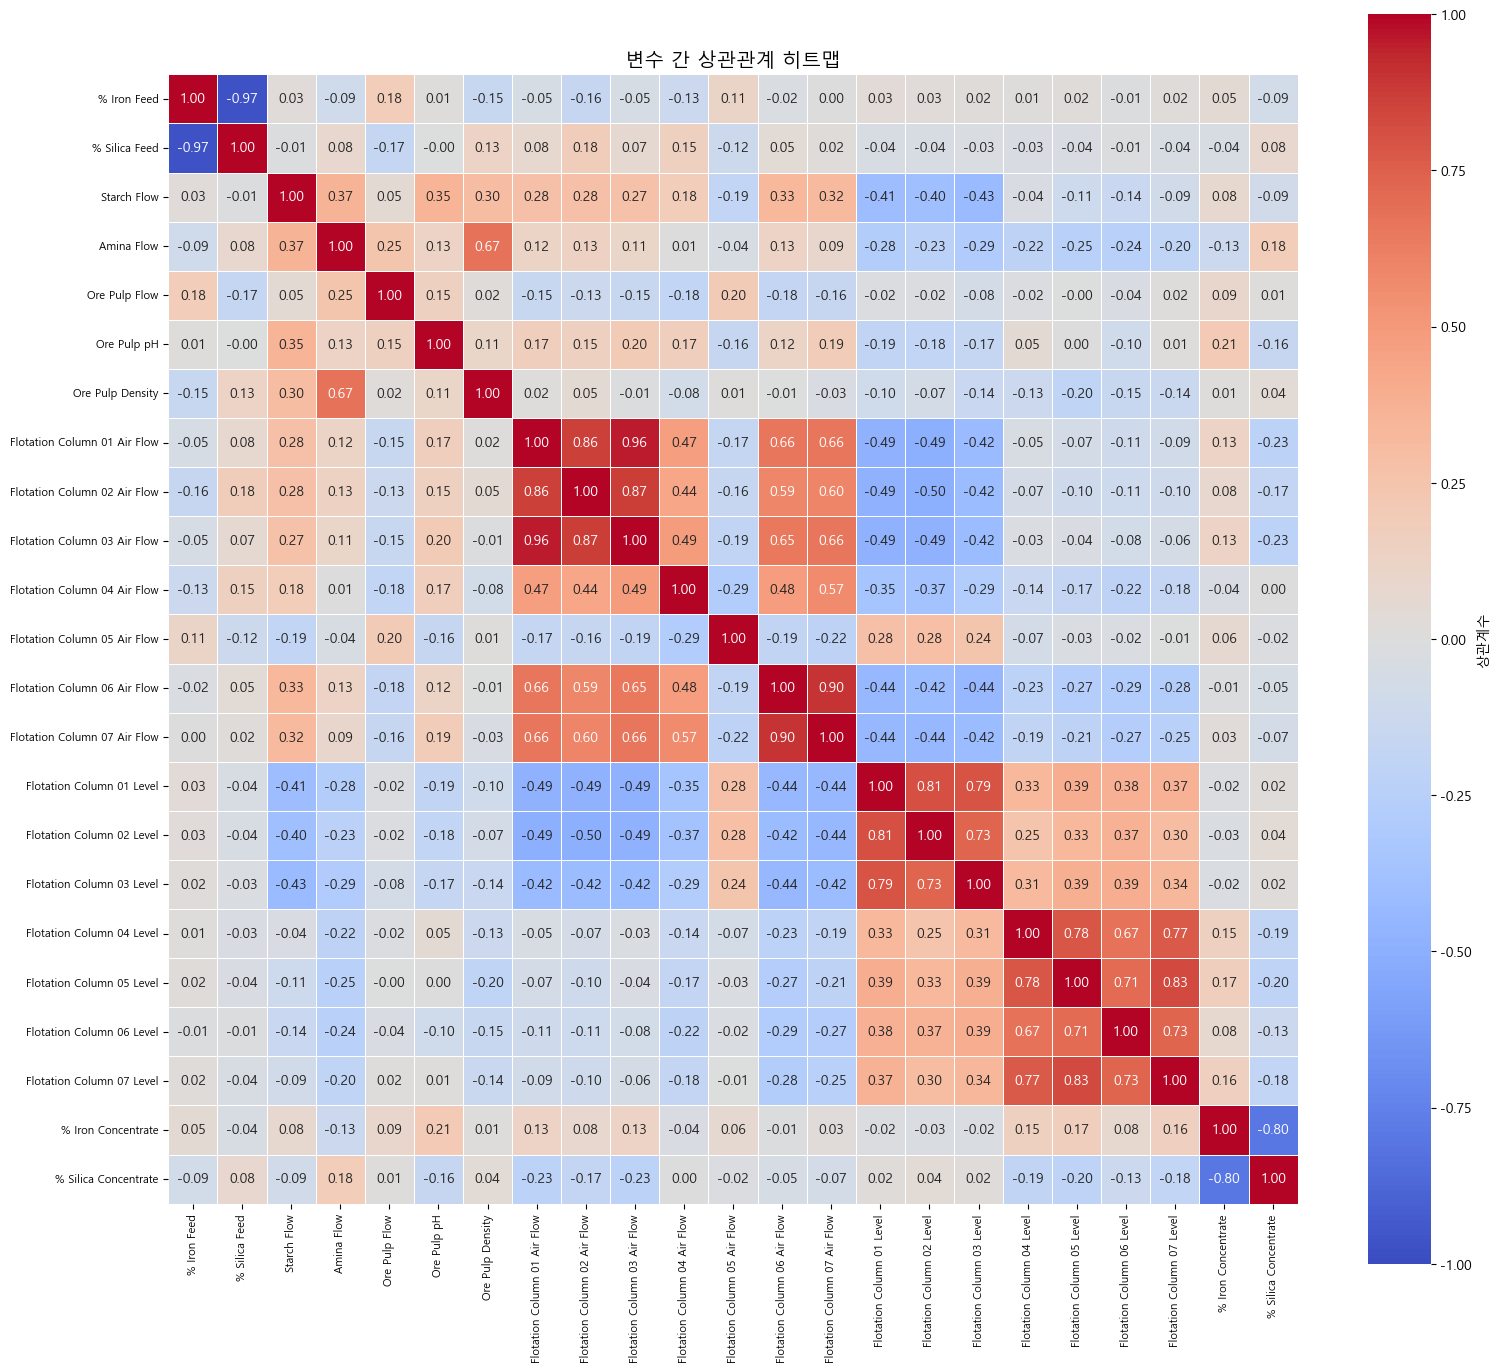

In [18]:
# ============================================================
# 변수 간 상관관계 히트맵
# ============================================================
corr = df_ts.select_dtypes(include='number').corr()

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr,
    annot=True,       # 23×23이면 False 권장 (True면 글자가 너무 작음)
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': '상관계수'},
)
plt.title("변수 간 상관관계 히트맵", fontsize=14)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

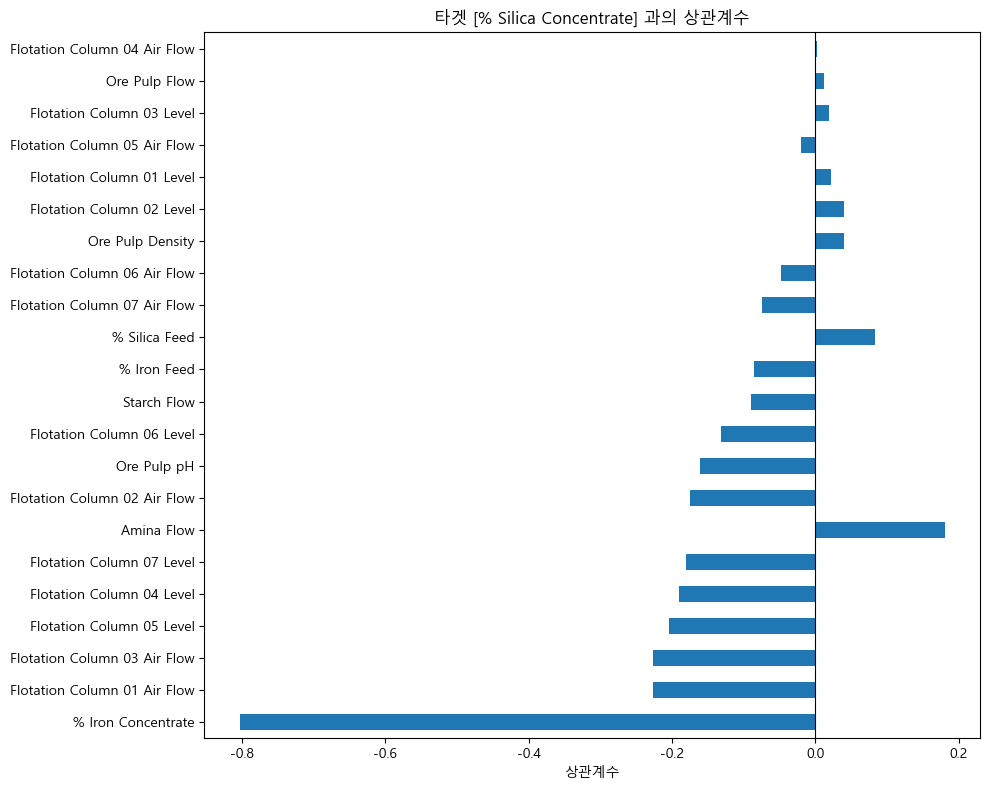

% Iron Concentrate             -0.802749
Flotation Column 01 Air Flow   -0.226252
Flotation Column 03 Air Flow   -0.226228
Flotation Column 05 Level      -0.203567
Flotation Column 04 Level      -0.189860
Flotation Column 07 Level      -0.180455
Amina Flow                      0.180346
Flotation Column 02 Air Flow   -0.174562
Ore Pulp pH                    -0.160985
Flotation Column 06 Level      -0.131257
Name: % Silica Concentrate, dtype: float64


In [19]:
target = '% Silica Concentrate'

# 타겟과 각 변수의 상관계수 (절댓값 큰 순)
target_corr = corr[target].drop(target).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 8))
target_corr.plot(kind='barh')
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'타겟 [{target}] 과의 상관계수')
plt.xlabel('상관계수')
plt.tight_layout()
plt.show()

print(target_corr.head(10))

In [ ]:
# ===== 1. 시계열 준비 =====
df_ts = df_reg.copy()
df_ts['date'] = pd.to_datetime(df_ts['date'])
df_ts = df_ts.sort_values('date').reset_index(drop=True)
num_cols = df_ts.select_dtypes(include='number').columns.tolist()

# ===== 2. 시계열 lineplot =====
n_cols, n_rows = 3, int(np.ceil(len(num_cols) / 3))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.lineplot(data=df_ts, x='date', y=col, ax=axes[i], linewidth=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('공정 변수별 시계열 변화', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ===== 3. 상관 히트맵 =====
corr = df_ts.select_dtypes(include='number').corr()
plt.figure(figsize=(16, 14))
sns.heatmap(corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title('변수 간 상관관계 히트맵')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# ===== 4. 강한 상관쌍 =====
pairs = corr.abs().unstack()
pairs = pairs[pairs < 1.0].drop_duplicates().sort_values(ascending=False)
print(pairs[pairs >= 0.8])

---
## A-2) 데이터 전처리

### A-2-1) 불필요한 변수 제거 및 결측치 확인

**[과제]** 써니는 Heatmap을 통해 타겟변수와 강한 상관관계를 가지는 변수를 발견하였습니다. 해당 변수가 데이터 누수를 유발할 수 있는지가 궁금해졌습니다. AI와 함께 상의하여 해당 변수 제거 여부를 검토하고 결정해보세요.

In [20]:
# ============================================================
# 상관관계 분석 + 누수 변수 제거
# ============================================================
target = '% Silica Concentrate'
threshold = 0.7

# 수치형 상관계수 행렬
corr = df_reg.select_dtypes(include='number').corr()

# ------------------------------------------------------------
# 1) 변수 간 상관관계 ≥ 0.7 (다중공선성 후보)
# ------------------------------------------------------------
corr_pairs = corr.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0]          # 자기 자신(=1) 제외
corr_pairs = corr_pairs.drop_duplicates()        # (A,B)/(B,A) 중복 제거
corr_pairs = corr_pairs.sort_values(ascending=False)

high_corr_pairs = corr_pairs[corr_pairs >= threshold]

print("=" * 60)
print(f"1. 변수 간 |상관계수| ≥ {threshold} 인 쌍")
print("=" * 60)
print(f"총 {len(high_corr_pairs)}쌍\n")

for (var1, var2), abs_r in high_corr_pairs.items():
    r = corr.loc[var1, var2]
    print(f"  {var1}")
    print(f"    ↔ {var2}")
    print(f"    r = {r:+.4f}  (|r| = {abs_r:.4f})\n")

1. 변수 간 |상관계수| ≥ 0.7 인 쌍
총 14쌍

  % Iron Feed
    ↔ % Silica Feed
    r = -0.9720  (|r| = 0.9720)

  Flotation Column 01 Air Flow
    ↔ Flotation Column 03 Air Flow
    r = +0.9583  (|r| = 0.9583)

  Flotation Column 06 Air Flow
    ↔ Flotation Column 07 Air Flow
    r = +0.9030  (|r| = 0.9030)

  Flotation Column 02 Air Flow
    ↔ Flotation Column 03 Air Flow
    r = +0.8749  (|r| = 0.8749)

  Flotation Column 01 Air Flow
    ↔ Flotation Column 02 Air Flow
    r = +0.8619  (|r| = 0.8619)

  Flotation Column 05 Level
    ↔ Flotation Column 07 Level
    r = +0.8298  (|r| = 0.8298)

  Flotation Column 01 Level
    ↔ Flotation Column 02 Level
    r = +0.8072  (|r| = 0.8072)

  % Iron Concentrate
    ↔ % Silica Concentrate
    r = -0.8027  (|r| = 0.8027)

  Flotation Column 01 Level
    ↔ Flotation Column 03 Level
    r = +0.7948  (|r| = 0.7948)

  Flotation Column 04 Level
    ↔ Flotation Column 05 Level
    r = +0.7845  (|r| = 0.7845)

  Flotation Column 04 Level
    ↔ Flotation Column 0

In [21]:
# ------------------------------------------------------------
# 2) 타겟과 |상관계수| ≥ 0.7 인 변수
# ------------------------------------------------------------
target_corr = corr[target].drop(target).sort_values(key=abs, ascending=False)
high_target_corr = target_corr[target_corr.abs() >= threshold]

print("=" * 60)
print(f"2. 타겟 [{target}] 과 |상관계수| ≥ {threshold}")
print("=" * 60)
print(high_target_corr)
print(f"\n총 {len(high_target_corr)}개")

2. 타겟 [% Silica Concentrate] 과 |상관계수| ≥ 0.7
% Iron Concentrate   -0.802749
Name: % Silica Concentrate, dtype: float64

총 1개


In [22]:
# ------------------------------------------------------------
# 3) 데이터 누수 변수 판단 및 제거
# ------------------------------------------------------------
print("=" * 60)
print("3. 데이터 누수 변수 검토")
print("=" * 60)

# 제거 사유 정리
leakage_info = {
    'date': '시간 식별자 — 모델 입력으로 부적합 (시계열 분할에만 사용)',
    '% Iron Concentrate': (
        '타겟(% Silica Concentrate)과 동시에 실험실에서 측정된 정광 결과값\n'
        '      → 미래 정보가 아니라 "같은 시점 결과"가 입력으로 들어가 누수 발생\n'
        f'      → 타겟과 상관 r = {corr.loc["% Iron Concentrate", target]:+.4f}'
    ),
}

for col, reason in leakage_info.items():
    print(f"  [{col}]")
    print(f"    {reason}\n")

# 실제 제거
drop_cols = ['date', '% Iron Concentrate']
df_reg_clean = df_reg.drop(columns=drop_cols)

print("=" * 60)
print("4. 변수 제거 결과")
print("=" * 60)
print("제거 변수 :", drop_cols)
print("제거 전 :", df_reg.shape)
print("제거 후 :", df_reg_clean.shape)
print("남은 변수 :", list(df_reg_clean.columns))
df_reg_clean.head()

3. 데이터 누수 변수 검토
  [date]
    시간 식별자 — 모델 입력으로 부적합 (시계열 분할에만 사용)

  [% Iron Concentrate]
    타겟(% Silica Concentrate)과 동시에 실험실에서 측정된 정광 결과값
      → 미래 정보가 아니라 "같은 시점 결과"가 입력으로 들어가 누수 발생
      → 타겟과 상관 r = -0.8027

4. 변수 제거 결과
제거 변수 : ['date', '% Iron Concentrate']
제거 전 : (3948, 24)
제거 후 : (3948, 22)
남은 변수 : ['% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow', 'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density', 'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow', 'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow', 'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow', 'Flotation Column 07 Air Flow', 'Flotation Column 01 Level', 'Flotation Column 02 Level', 'Flotation Column 03 Level', 'Flotation Column 04 Level', 'Flotation Column 05 Level', 'Flotation Column 06 Level', 'Flotation Column 07 Level', '% Silica Concentrate']


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Silica Concentrate
0,60.18,9.34,1060.859297,379.836203,400.982539,9.527187,1.550374,200.035839,195.577700,199.983717,...,250.069722,249.992956,753.724247,726.559437,860.557818,477.349197,452.512522,478.219647,470.105547,1.36
1,60.18,9.34,2034.926525,322.233975,400.468947,9.700679,1.532017,199.990122,195.106250,199.765344,...,250.029056,250.059711,848.675503,777.784437,869.419421,483.816131,469.448172,471.607075,462.665478,1.43
2,60.18,9.34,1435.425811,474.656322,399.157083,9.687788,1.645200,200.019311,195.604928,199.925800,...,249.979356,250.111328,851.951492,776.293654,879.704989,456.147231,453.227000,447.708467,453.475667,1.33
3,60.18,9.34,618.460387,396.377733,398.942522,9.851689,1.559929,199.940833,195.657094,200.044339,...,249.978589,250.028506,855.910630,780.369869,882.093896,449.410744,448.581506,450.697578,448.660094,1.27
4,59.54,9.56,1367.502858,317.134072,400.836283,9.936163,1.530984,199.878922,196.162864,199.905467,...,250.061661,250.122067,851.603513,784.446084,884.840698,450.123050,451.774694,451.574422,449.406894,5.50


### A-2-2) 입출력 변수 분할 및 데이터 분할

**[과제]** 써니는 `% Silica Concentrate`를 예측하기 위해 입력변수와 타겟 변수를 분리하려고 합니다. Day 2와 마찬가지로 시계열 데이터라는 점을 고려하여 데이터를 분할해보세요.

In [23]:
# ============================================================
# 시계열 분할 준비
# ============================================================
# date는 분할 기간 확인용으로 유지, 모델 입력에서는 제외
df_reg_ts = df_reg.copy()
df_reg_ts['date'] = pd.to_datetime(df_reg_ts['date'])
df_reg_ts = df_reg_ts.sort_values('date').reset_index(drop=True)

# 누수 변수 제거 (% Iron Concentrate)
df_reg_ts = df_reg_ts.drop(columns=['% Iron Concentrate'])

print("시계열 데이터 크기 :", df_reg_ts.shape)
print("수집 기간 :", df_reg_ts['date'].min(), "~", df_reg_ts['date'].max())
df_reg_ts.head()

시계열 데이터 크기 : (3948, 23)
수집 기간 : 2017-03-29 12:00:00 ~ 2017-09-09 23:00:00


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Silica Concentrate
0,2017-03-29 12:00:00,60.18,9.34,1060.859297,379.836203,400.982539,9.527187,1.550374,200.035839,195.577700,...,250.069722,249.992956,753.724247,726.559437,860.557818,477.349197,452.512522,478.219647,470.105547,1.36
1,2017-03-29 13:00:00,60.18,9.34,2034.926525,322.233975,400.468947,9.700679,1.532017,199.990122,195.106250,...,250.029056,250.059711,848.675503,777.784437,869.419421,483.816131,469.448172,471.607075,462.665478,1.43
2,2017-03-29 14:00:00,60.18,9.34,1435.425811,474.656322,399.157083,9.687788,1.645200,200.019311,195.604928,...,249.979356,250.111328,851.951492,776.293654,879.704989,456.147231,453.227000,447.708467,453.475667,1.33
3,2017-03-29 15:00:00,60.18,9.34,618.460387,396.377733,398.942522,9.851689,1.559929,199.940833,195.657094,...,249.978589,250.028506,855.910630,780.369869,882.093896,449.410744,448.581506,450.697578,448.660094,1.27
4,2017-03-29 16:00:00,59.54,9.56,1367.502858,317.134072,400.836283,9.936163,1.530984,199.878922,196.162864,...,250.061661,250.122067,851.603513,784.446084,884.840698,450.123050,451.774694,451.574422,449.406894,5.50


In [24]:
# ============================================================
# 시간 순서 기반 분할 (앞 80% 학습, 뒤 20% 테스트)
# ============================================================
test_ratio = 0.2
split_idx = int(len(df_reg_ts) * (1 - test_ratio))
train_ts = df_reg_ts.iloc[:split_idx]   # 앞 80% — 과거
test_ts  = df_reg_ts.iloc[split_idx:]   # 뒤 20% — 미래
print("학습 기간 :", train_ts['date'].min(), "~", train_ts['date'].max())
print("테스트 기간 :", test_ts['date'].min(), "~", test_ts['date'].max())
print("학습 행 수 :", len(train_ts), "/ 테스트 행 수 :", len(test_ts))

학습 기간 : 2017-03-29 12:00:00 ~ 2017-08-08 01:00:00
테스트 기간 : 2017-08-08 02:00:00 ~ 2017-09-09 23:00:00
학습 행 수 : 3158 / 테스트 행 수 : 790


In [25]:
# ============================================================
# 입출력 변수 분리
# ============================================================
target = '% Silica Concentrate'
# date, 타겟을 제외한 나머지 = 입력 변수 (21개)
feature_cols = df_reg_ts.columns.drop(['date', target])
X_train = train_ts[feature_cols]
Y_train = train_ts[target]
X_test  = test_ts[feature_cols]
Y_test  = test_ts[target]
print("입력변수 개수 :", len(feature_cols))
print("학습 데이터   :", X_train.shape, Y_train.shape)
print("테스트 데이터 :", X_test.shape, Y_test.shape)
print("\n타겟 변수 :", target)
print("입력 변수 목록 :")
print(list(feature_cols))

입력변수 개수 : 21
학습 데이터   : (3158, 21) (3158,)
테스트 데이터 : (790, 21) (790,)

타겟 변수 : % Silica Concentrate
입력 변수 목록 :
['% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow', 'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density', 'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow', 'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow', 'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow', 'Flotation Column 07 Air Flow', 'Flotation Column 01 Level', 'Flotation Column 02 Level', 'Flotation Column 03 Level', 'Flotation Column 04 Level', 'Flotation Column 05 Level', 'Flotation Column 06 Level', 'Flotation Column 07 Level']


### A-2-3) 스케일링 필요 여부 검토

**[과제]** 써니는 Day 2에서는 Ridge/Lasso 모델 특성 때문에 StandardScaler를 적용했었는데 Day 3에서 사용할 Random Forest·GBM·XGBoost·LightGBM·CatBoost도 스케일링이 꼭 필요한지 AI와 상의해서 판단해 보세요.

In [26]:
# ============================================================
# A-2-3) 스케일링 — Ridge/Lasso (및 Day 2 선형 모델 비교용)
# ============================================================

# 회귀 데이터는 전부 수치형 → 모든 입력 변수 스케일링
num_features = X_train.columns.tolist()
print("스케일링 대상 변수 수 :", len(num_features))

# StandardScaler: 평균 0, 표준편차 1로 변환
#   z = (x - mean) / std
scaler = StandardScaler()

# ★ 중요: train으로만 fit → test는 transform만 (데이터 누수 방지)
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[num_features] = scaler.fit_transform(X_train[num_features])
X_test_scaled[num_features]  = scaler.transform(X_test[num_features])

print("스케일링 전 (학습) — 일부 변수 범위")
print(X_train[num_features[:3]].describe().loc[['min', 'max']])

print("\n스케일링 후 (학습) — 동일 변수")
print(X_train_scaled[num_features[:3]].describe().loc[['mean', 'std']])

print("\n스케일링 후 shape")
print("X_train_scaled :", X_train_scaled.shape)
print("X_test_scaled  :", X_test_scaled.shape)
X_train_scaled.head()

스케일링 대상 변수 수 : 21
스케일링 전 (학습) — 일부 변수 범위
     % Iron Feed  % Silica Feed  Starch Flow
min        43.37           3.85    54.595483
max        64.48          32.23  6187.232444

스케일링 후 (학습) — 동일 변수
       % Iron Feed  % Silica Feed   Starch Flow
mean  1.349986e-15  -5.399945e-17  5.399945e-16
std   1.000158e+00   1.000158e+00  1.000158e+00

스케일링 후 shape
X_train_scaled : (3158, 21)
X_test_scaled  : (790, 21)


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 05 Air Flow,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level
0,0.635935,-0.699104,-1.780479,-1.334504,0.263303,-0.880527,-1.916130,-2.523629,-2.586622,-2.637053,...,2.083594,-1.491997,-1.528020,1.761698,1.592667,2.253049,0.772828,0.374203,0.714697,0.694274
1,0.635935,-0.699104,-0.778146,-2.030641,0.166342,-0.366070,-2.192761,-2.525124,-2.602218,-2.644393,...,2.083594,-1.493559,-1.525420,2.494532,2.004140,2.314311,0.860774,0.609549,0.623222,0.587949
2,0.635935,-0.699104,-1.395043,-0.188579,-0.081324,-0.404299,-0.487207,-2.524170,-2.585721,-2.639000,...,2.083594,-1.495468,-1.523410,2.519816,1.992165,2.385417,0.484497,0.384132,0.292624,0.456618
3,0.635935,-0.699104,-2.235715,-1.134595,-0.121831,0.081719,-1.772152,-2.526736,-2.583995,-2.635015,...,2.083594,-1.495498,-1.526635,2.550372,2.024908,2.401932,0.392886,0.319576,0.333973,0.387799
4,0.512924,-0.666147,-1.464937,-2.092275,0.235691,0.332210,-2.208328,-2.528761,-2.567264,-2.639683,...,2.083594,-1.492307,-1.522992,2.517130,2.057651,2.420921,0.402572,0.363950,0.346103,0.398472


In [27]:
# ============================================================
# 트리 기반 앙상블 — 스케일링 불필요
# ============================================================
print("=" * 60)
print("트리 기반 앙상블 모델 스케일링 판단")
print("=" * 60)
print("""
[판단] Random Forest, GBM, XGBoost, LightGBM, CatBoost
  → 스케일링 불필요

[이유]
  1) 분할 기준은 "변수 값 > 임계값" 형태
  2) 전체 데이터를 같은 비율로 나누면 분할 결과 동일
     (예: Starch Flow > 1500  ↔  스케일 후 > -0.3)
  3) 스케일링해도 성능은 거의 같고, 해석만 어려워짐

[사용 데이터]
  → X_train, X_test (원본) 그대로 사용
""")

# 앙상블용 변수명 (명확히 구분)
X_train_tree = X_train.copy()
X_test_tree  = X_test.copy()

print("앙상블 모델 입력 shape :", X_train_tree.shape, X_test_tree.shape)

트리 기반 앙상블 모델 스케일링 판단

[판단] Random Forest, GBM, XGBoost, LightGBM, CatBoost
  → 스케일링 불필요

[이유]
  1) 분할 기준은 "변수 값 > 임계값" 형태
  2) 전체 데이터를 같은 비율로 나누면 분할 결과 동일
     (예: Starch Flow > 1500  ↔  스케일 후 > -0.3)
  3) 스케일링해도 성능은 거의 같고, 해석만 어려워짐

[사용 데이터]
  → X_train, X_test (원본) 그대로 사용

앙상블 모델 입력 shape : (3158, 21) (790, 21)


---
## A-3) 모델 학습 및 예측

**[과제]** 써니는 Day 2에서 학습한 회귀 모델과 Day 3에서 학습한 앙상블 모델을 동일한 데이터셋에 적용하여 성능을 비교해 보고자 합니다. AI와 함께 모델 학습, 예측, 성능 평가 코드를 작성하고, 여러 모델의 결과를 한눈에 비교할 수 있는 방법을 찾아 성능을 비교 및 분석해 보세요.

In [28]:
def eval_reg(model, X_tr, y_tr, X_te, y_te, name=""):
    """회귀 모델 학습 + 테스트 성능 반환"""
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    mae  = mean_absolute_error(y_te, pred)
    r2   = r2_score(y_te, pred)
    print(f"[{name}]")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    return {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2, "fitted": model, "pred": pred}

results = []   # 모든 모델 결과를 여기에 모음

In [31]:
# ============================================================
# 1. Ridge / Lasso — StandardScaler 적용 데이터 사용
# ============================================================
ridge = Ridge(alpha=1.0)          # Day 2 시계열 분할 기준
lasso = Lasso(alpha=0.01, max_iter=10000)

results.append(eval_reg(ridge, X_train_scaled, Y_train, X_test_scaled, Y_test, "Ridge"))
results.append(eval_reg(lasso, X_train_scaled, Y_train, X_test_scaled, Y_test, "Lasso"))

[Ridge]
  RMSE : 1.1730
  MAE  : 0.9038
  R²   : -0.0410
[Lasso]
  RMSE : 1.0947
  MAE  : 0.8576
  R²   : 0.0933


In [32]:
# ============================================================
# 2. 트리 기반 앙상블 단일 모델 — 원본 데이터 (스케일링 X)
# ============================================================
X_tr = X_train_tree   # = X_train
X_te = X_test_tree    # = X_test
y_tr, y_te = Y_train, Y_test

# --- Random Forest ---
rf = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
results.append(eval_reg(rf, X_tr, y_tr, X_te, y_te, "Random Forest"))

# --- GBM (sklearn) ---
gbm = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
)
results.append(eval_reg(gbm, X_tr, y_tr, X_te, y_te, "GBM"))

# --- XGBoost ---
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
)
results.append(eval_reg(xgb, X_tr, y_tr, X_te, y_te, "XGBoost"))

# --- LightGBM ---
lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    verbose=-1,
    n_jobs=-1,
)
results.append(eval_reg(lgbm, X_tr, y_tr, X_te, y_te, "LightGBM"))

# --- CatBoost ---
cat = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=5,
    random_state=42,
    verbose=0,
)
results.append(eval_reg(cat, X_tr, y_tr, X_te, y_te, "CatBoost"))

[Random Forest]
  RMSE : 1.1131
  MAE  : 0.9095
  R²   : 0.0627
[GBM]
  RMSE : 1.1249
  MAE  : 0.9187
  R²   : 0.0427
[XGBoost]
  RMSE : 1.0842
  MAE  : 0.8697
  R²   : 0.1106
[LightGBM]
  RMSE : 1.0718
  MAE  : 0.8464
  R²   : 0.1308
[CatBoost]
  RMSE : 1.0678
  MAE  : 0.8617
  R²   : 0.1373


In [33]:
from sklearn.ensemble import VotingRegressor

# ============================================================
# 3. Voting 앙상블 (추천: RF + XGB + LGBM + CatBoost)
# ============================================================
voting_reg = VotingRegressor(
    estimators=[
        ('rf',   RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                       random_state=42, n_jobs=-1)),
        ('xgb',  XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                               random_state=42, n_jobs=-1)),
        ('lgbm', LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                                random_state=42, verbose=-1, n_jobs=-1)),
        ('cat',  CatBoostRegressor(iterations=300, learning_rate=0.05, depth=5,
                                    random_state=42, verbose=0)),
    ],
    n_jobs=-1,
)

results.append(eval_reg(voting_reg, X_tr, y_tr, X_te, y_te, "Voting Ensemble (RF+XGB+LGBM+CAT)"))

[Voting Ensemble (RF+XGB+LGBM+CAT)]
  RMSE : 1.0705
  MAE  : 0.8622
  R²   : 0.1330


In [34]:
# ============================================================
# 4. 성능 비교표 + 시각화
# ============================================================
compare_df = pd.DataFrame(results)[["model", "RMSE", "MAE", "R2"]]
compare_df = compare_df.sort_values("R2", ascending=False).reset_index(drop=True)
compare_df["RMSE"] = compare_df["RMSE"].round(4)
compare_df["MAE"]  = compare_df["MAE"].round(4)
compare_df["R2"]   = compare_df["R2"].round(4)

print("=" * 60)
print("회귀 모델 성능 비교 (테스트셋)")
print("=" * 60)
display(compare_df)

# 최고 모델
best = compare_df.iloc[0]
print(f"\n최고 모델 : {best['model']}  (R²={best['R2']}, RMSE={best['RMSE']})")

회귀 모델 성능 비교 (테스트셋)


,model,RMSE,MAE,R2
0,CatBoost,1.0678,0.8617,0.1373
1,Voting Ensemble (RF+XGB+LGBM+CAT),1.0705,0.8622,0.1330
2,LightGBM,1.0718,0.8464,0.1308
3,XGBoost,1.0842,0.8697,0.1106
4,Lasso,1.0947,0.8576,0.0933
5,Random Forest,1.1131,0.9095,0.0627
6,GBM,1.1249,0.9187,0.0427
7,Ridge,1.1730,0.9038,-0.0410



최고 모델 : CatBoost  (R²=0.1373, RMSE=1.0678)


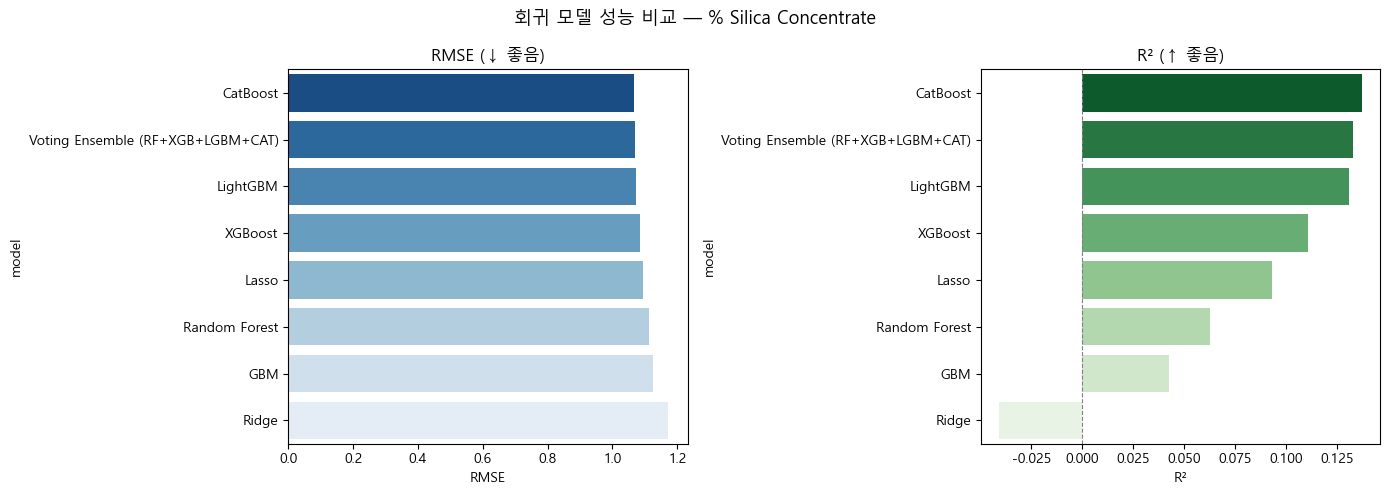

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE (낮을수록 좋음)
sns.barplot(data=compare_df, y="model", x="RMSE", ax=axes[0], palette="Blues_r")
axes[0].set_title("RMSE (↓ 좋음)")
axes[0].set_xlabel("RMSE")

# R² (높을수록 좋음)
sns.barplot(data=compare_df, y="model", x="R2", ax=axes[1], palette="Greens_r")
axes[1].set_title("R² (↑ 좋음)")
axes[1].set_xlabel("R²")
axes[1].axvline(0, color="gray", linestyle="--", linewidth=0.8)

plt.suptitle("회귀 모델 성능 비교 — % Silica Concentrate", fontsize=13)
plt.tight_layout()
plt.show()

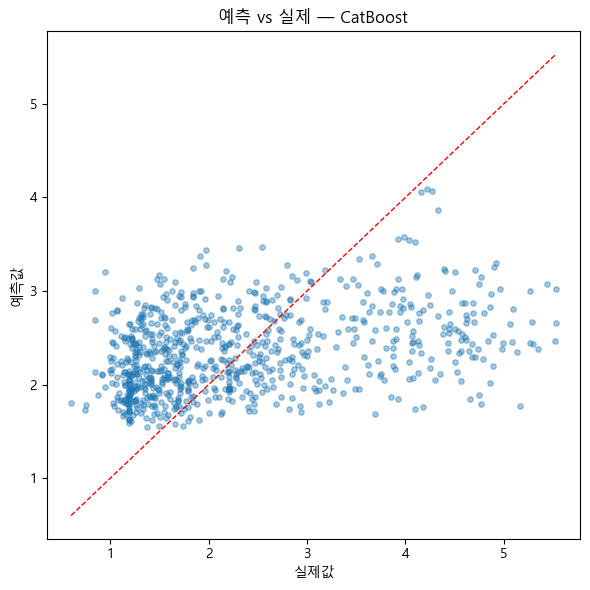

In [36]:
best_name = compare_df.iloc[0]["model"]
best_pred = next(r["pred"] for r in results if r["model"] == best_name)

plt.figure(figsize=(6, 6))
plt.scatter(Y_test, best_pred, alpha=0.4, s=15)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], "r--", lw=1)
plt.xlabel("실제값")
plt.ylabel("예측값")
plt.title(f"예측 vs 실제 — {best_name}")
plt.tight_layout()
plt.show()

다중공진성 변수 제거

다중공선성 탐색 (|r| >= 0.7)
강한 상관쌍: 13개

  % Iron Feed
    ↔ % Silica Feed
    r = -0.9720  → 제거: % Silica Feed

  Flotation Column 01 Air Flow
    ↔ Flotation Column 03 Air Flow
    r = +0.9583  → 제거: Flotation Column 03 Air Flow

  Flotation Column 06 Air Flow
    ↔ Flotation Column 07 Air Flow
    r = +0.9030  → 제거: Flotation Column 06 Air Flow

  Flotation Column 02 Air Flow
    ↔ Flotation Column 03 Air Flow
    r = +0.8749  → 제거: Flotation Column 02 Air Flow

  Flotation Column 01 Air Flow
    ↔ Flotation Column 02 Air Flow
    r = +0.8619  → 제거: Flotation Column 02 Air Flow

  Flotation Column 05 Level
    ↔ Flotation Column 07 Level
    r = +0.8298  → 제거: Flotation Column 07 Level

  Flotation Column 01 Level
    ↔ Flotation Column 02 Level
    r = +0.8072  → 제거: Flotation Column 01 Level

  Flotation Column 01 Level
    ↔ Flotation Column 03 Level
    r = +0.7948  → 제거: Flotation Column 01 Level

  Flotation Column 04 Level
    ↔ Flotation Column 05 Level
    r = +0.7845  → 제거: Flot

,model,RMSE_orig,R2_orig,RMSE_mc,R2_mc,dR2
0,CatBoost,1.0678,0.1373,1.0532,0.1608,0.0234
1,Voting Ensemble,1.0705,0.1330,1.0531,0.1610,0.0279
2,LightGBM,1.0718,0.1308,1.0742,0.1270,-0.0039
3,XGBoost,1.0842,0.1106,1.0755,0.1248,0.0142
4,Lasso,1.0947,0.0933,1.0907,0.1000,0.0068
5,Random Forest,1.1131,0.0627,1.0751,0.1256,0.0629
6,GBM,1.1249,0.0427,1.0669,0.1388,0.0961
7,Ridge,1.1730,-0.0410,1.0846,0.1100,0.1510


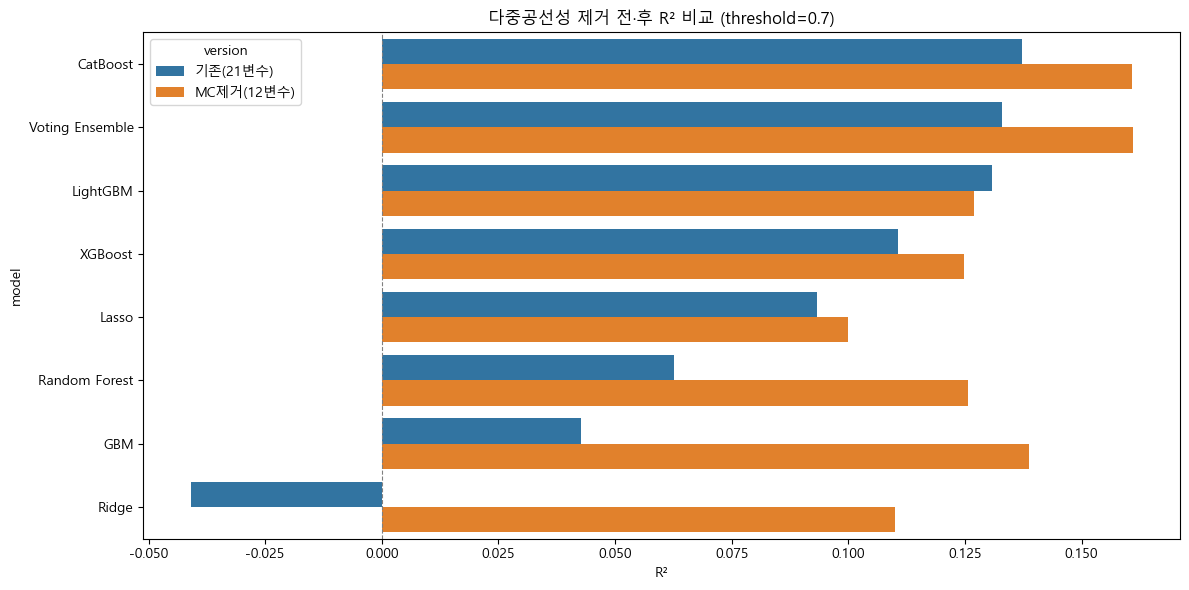

In [44]:
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import Ridge, Lasso

# ── 설정 ──
leakage_cols = ['date', '% Iron Concentrate']
target = '% Silica Concentrate'
threshold = 0.7   # 다중공선성 기준

# ── 데이터 준비 (시계열 정렬) ──
df_base = df_reg.copy()
df_base['date'] = pd.to_datetime(df_base['date'])
df_base = df_base.sort_values('date').reset_index(drop=True)

# ── [1] threshold 기준 상관쌍 탐색 + 제거 변수 자동 선정 ──
def find_mc_drop_cols(df, target, leakage_cols, threshold=0.7):
    """
    |r| >= threshold 인 변수 쌍을 찾고,
    각 쌍에서 타겟과 상관이 낮은 변수를 제거 대상으로 선정
    """
    feature_cols = [c for c in df.columns if c not in leakage_cols + [target]]
    corr = df[feature_cols + [target]].corr()

    # 변수 간 상관쌍 (|r| >= threshold)
    corr_pairs = corr.abs().unstack()
    corr_pairs = corr_pairs[corr_pairs < 1.0].drop_duplicates()
    high_pairs = corr_pairs[corr_pairs >= threshold].sort_values(ascending=False)

    # 타겟과의 상관 (절댓값)
    target_corr = corr[target].drop(target).abs()

    to_drop = set()
    for (var1, var2), abs_r in high_pairs.items():
        if var1 in to_drop or var2 in to_drop:
            continue
        if var1 == target or var2 == target:
            continue
        # 타겟 상관이 낮은 변수 제거
        drop_var = var1 if target_corr.get(var1, 0) < target_corr.get(var2, 0) else var2
        to_drop.add(drop_var)

    return sorted(to_drop), high_pairs, feature_cols

mc_drop_cols, high_pairs, _ = find_mc_drop_cols(df_base, target, leakage_cols, threshold)

print("=" * 70)
print(f"다중공선성 탐색 (|r| >= {threshold})")
print("=" * 70)
print(f"강한 상관쌍: {len(high_pairs)}개\n")
for (var1, var2), abs_r in high_pairs.items():
    r = df_base[[var1, var2]].corr().iloc[0, 1]
    mark = ""
    if var1 in mc_drop_cols:
        mark = f"  → 제거: {var1}"
    elif var2 in mc_drop_cols:
        mark = f"  → 제거: {var2}"
    print(f"  {var1}")
    print(f"    ↔ {var2}")
    print(f"    r = {r:+.4f}{mark}\n")

print(f"자동 제거 변수 ({len(mc_drop_cols)}개): {mc_drop_cols}\n")

# ── [2] feature 목록 구성 ──
drop_orig = leakage_cols
feat_orig = [c for c in df_base.columns if c not in drop_orig + [target]]

drop_mc = leakage_cols + mc_drop_cols
feat_mc = [c for c in df_base.columns if c not in drop_mc + [target]]

print(f"기존 입력 변수: {len(feat_orig)}개")
print(f"MC 제거 후   : {len(feat_mc)}개")

# 제거 후 남은 쌍의 최대 상관 확인
if len(feat_mc) > 1:
    remain_max = df_base[feat_mc].corr().abs().unstack()
    remain_max = remain_max[remain_max < 1.0].drop_duplicates().max()
    print(f"제거 후 변수쌍 최대 |r|: {remain_max:.4f}\n")

# ── [3] 이하 기존과 동일 ──
def make_split(feat_cols):
    split_idx = int(len(df_base) * 0.8)
    train, test = df_base.iloc[:split_idx], df_base.iloc[split_idx:]
    X_tr, X_te = train[feat_cols], test[feat_cols]
    y_tr, y_te = train[target], test[target]
    sc = StandardScaler()
    X_tr_s = pd.DataFrame(sc.fit_transform(X_tr), columns=feat_cols, index=X_tr.index)
    X_te_s = pd.DataFrame(sc.transform(X_te), columns=feat_cols, index=X_te.index)
    return X_tr, X_te, X_tr_s, X_te_s, y_tr, y_te

X_tr_o, X_te_o, X_tr_os, X_te_os, y_tr, y_te = make_split(feat_orig)
X_tr_m, X_te_m, X_tr_ms, X_te_ms, _, _     = make_split(feat_mc)

def eval_reg(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    return {
        'RMSE': np.sqrt(mean_squared_error(y_te, pred)),
        'MAE': mean_absolute_error(y_te, pred),
        'R2': r2_score(y_te, pred),
    }

def get_models():
    return {
        'Ridge': Ridge(alpha=1.0),
        'Lasso': Lasso(alpha=0.01, max_iter=10000),
        'Random Forest': RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=42, n_jobs=-1),
        'GBM': GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42),
        'XGBoost': XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42, n_jobs=-1),
        'LightGBM': LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42, verbose=-1, n_jobs=-1),
        'CatBoost': CatBoostRegressor(iterations=300, learning_rate=0.05, depth=5, random_state=42, verbose=0),
        'Voting Ensemble': VotingRegressor(estimators=[
            ('rf', RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=42, n_jobs=-1)),
            ('xgb', XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42, n_jobs=-1)),
            ('lgbm', LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42, verbose=-1, n_jobs=-1)),
            ('cat', CatBoostRegressor(iterations=300, learning_rate=0.05, depth=5, random_state=42, verbose=0)),
        ], n_jobs=-1),
    }

rows = []
for name, model in get_models().items():
    use_scaled = name in ['Ridge', 'Lasso']
    if use_scaled:
        m_orig = eval_reg(model, X_tr_os, y_tr, X_te_os, y_te)
        m_mc   = eval_reg(model, X_tr_ms, y_tr, X_te_ms, y_te)
    else:
        m_orig = eval_reg(model, X_tr_o, y_tr, X_te_o, y_te)
        m_mc   = eval_reg(model, X_tr_m, y_tr, X_te_m, y_te)
    rows.append({
        'model': name,
        'RMSE_orig': m_orig['RMSE'], 'R2_orig': m_orig['R2'],
        'RMSE_mc': m_mc['RMSE'],     'R2_mc': m_mc['R2'],
        'dR2': round(m_mc['R2'] - m_orig['R2'], 4),
    })

cmp = pd.DataFrame(rows).round(4).sort_values('R2_orig', ascending=False).reset_index(drop=True)

print("=" * 70)
print("기존(21변수) vs 다중공선성 제거(12변수) 성능 비교")
print("=" * 70)
display(cmp)

plot_df = cmp.melt(id_vars='model', value_vars=['R2_orig', 'R2_mc'],
                   var_name='version', value_name='R2')
plot_df['version'] = plot_df['version'].map({'R2_orig': '기존(21변수)', 'R2_mc': f'MC제거({len(feat_mc)}변수)'})

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, y='model', x='R2', hue='version')
plt.axvline(0, color='gray', linestyle='--', lw=0.8)
plt.title(f'다중공선성 제거 전·후 R² 비교 (threshold={threshold})')
plt.xlabel('R²')
plt.tight_layout()
plt.show()

---
## A-4) 모델 결과 분석 및 고도화

**[과제]** 써니는 Day 2에서 학습한 회귀 모델들과 Day 3에서 학습한 앙상블 모델들이 중요하다고 판단하는 공정 변수가 모델에 따라 얼마나 일관되게 나타나는지 궁금해졌습니다. AI와 함께 변수 중요도 및 회귀 계수를 비교할 수 있는 코드를 작성하고 여러 모델에서 공통적으로 중요하게 선정되는 핵심 공정 변수가 무엇인지 분석해 보세요.

In [38]:
# ============================================================
# A-4) 변수 중요도 · 회귀 계수 비교
# ============================================================
feature_names = X_train_tree.columns.tolist()   # 21개 입력 변수

# ── fitted 모델 꺼내기 (A-3 results 사용) ──
def get_fitted(name):
    return next(r['fitted'] for r in results if r['model'] == name)

models_tree = {
    'Random Forest': get_fitted('Random Forest'),
    'GBM':           get_fitted('GBM'),
    'XGBoost':       get_fitted('XGBoost'),
    'LightGBM':      get_fitted('LightGBM'),
    'CatBoost':      get_fitted('CatBoost'),
}
ridge_model = get_fitted('Ridge')
lasso_model = get_fitted('Lasso')

# results가 없다면 A-3 모델을 여기서 재학습 후 위 dict 구성

In [39]:
# ── 1) 회귀 계수 (Ridge / Lasso) ──
coef_df = pd.DataFrame({
    '변수': feature_names,
    'Ridge_계수': ridge_model.coef_,
    'Lasso_계수': lasso_model.coef_,
})
coef_df['Ridge_절대값'] = coef_df['Ridge_계수'].abs()
coef_df['Lasso_절대값'] = coef_df['Lasso_계수'].abs()
coef_df = coef_df.sort_values('Ridge_절대값', ascending=False).reset_index(drop=True)

print("=" * 60)
print("1. Ridge / Lasso 회귀 계수")
print("=" * 60)
display(coef_df)

1. Ridge / Lasso 회귀 계수


,변수,Ridge_계수,Lasso_계수,Ridge_절대값,Lasso_절대값
0,Amina Flow,0.323989,0.264520,0.323989,0.264520
1,Flotation Column 07 Air Flow,0.316192,0.029617,0.316192,0.029617
2,Flotation Column 01 Air Flow,-0.273571,-0.283736,0.273571,0.283736
3,Flotation Column 06 Air Flow,-0.269876,-0.000000,0.269876,0.000000
4,Flotation Column 04 Air Flow,0.218613,0.207759,0.218613,0.207759
5,Flotation Column 03 Air Flow,-0.199694,-0.117390,0.199694,0.117390
6,Flotation Column 05 Level,-0.171233,-0.147771,0.171233,0.147771
7,Ore Pulp Density,-0.155568,-0.116301,0.155568,0.116301
8,Starch Flow,-0.101792,-0.093102,0.101792,0.093102
9,% Silica Feed,0.096679,0.049894,0.096679,0.049894


In [40]:
# ── 2) 트리 모델 변수 중요도 ──
def norm_abs(arr):
    """절대값 → 합=1 정규화"""
    a = np.abs(arr)
    return a / a.sum() if a.sum() > 0 else a

imp_dict = {'변수': feature_names}

# 선형: 계수 절대값 정규화
imp_dict['Ridge'] = norm_abs(ridge_model.coef_)
imp_dict['Lasso'] = norm_abs(lasso_model.coef_)

# 트리: feature_importances_
for name, mdl in models_tree.items():
    imp_dict[name] = mdl.feature_importances_

imp_all = pd.DataFrame(imp_dict)
model_cols = [c for c in imp_all.columns if c != '변수']
imp_all['평균중요도'] = imp_all[model_cols].mean(axis=1)
imp_all = imp_all.sort_values('평균중요도', ascending=False).reset_index(drop=True)

print("=" * 60)
print("2. 모델별 변수 중요도 (정규화)")
print("=" * 60)
display(imp_all.round(4))

2. 모델별 변수 중요도 (정규화)


,변수,Ridge,Lasso,Random Forest,GBM,XGBoost,LightGBM,CatBoost,평균중요도
0,% Iron Feed,0.0195,0.0000,0.0310,0.0427,0.0346,296,7.0080,43.3051
1,Starch Flow,0.0405,0.0657,0.0451,0.0377,0.0236,297,3.3725,42.9407
2,Amina Flow,0.1288,0.1866,0.0830,0.0879,0.0516,289,10.6666,42.8864
3,% Silica Feed,0.0384,0.0352,0.0446,0.0706,0.0781,286,7.2204,41.9268
4,Flotation Column 03 Level,0.0133,0.0143,0.0448,0.0508,0.0439,256,3.9648,37.1617
5,Flotation Column 06 Level,0.0222,0.0000,0.0476,0.0433,0.0431,244,4.3349,35.4987
6,Flotation Column 01 Air Flow,0.1087,0.2002,0.0835,0.1137,0.1057,238,8.3049,35.2738
7,Flotation Column 01 Level,0.0090,0.0000,0.0384,0.0330,0.0347,242,3.3125,35.0611
8,Flotation Column 02 Level,0.0092,0.0000,0.0414,0.0366,0.0440,232,4.2422,33.7676
9,Ore Pulp pH,0.0186,0.0369,0.0413,0.0328,0.0284,232,3.0857,33.6062


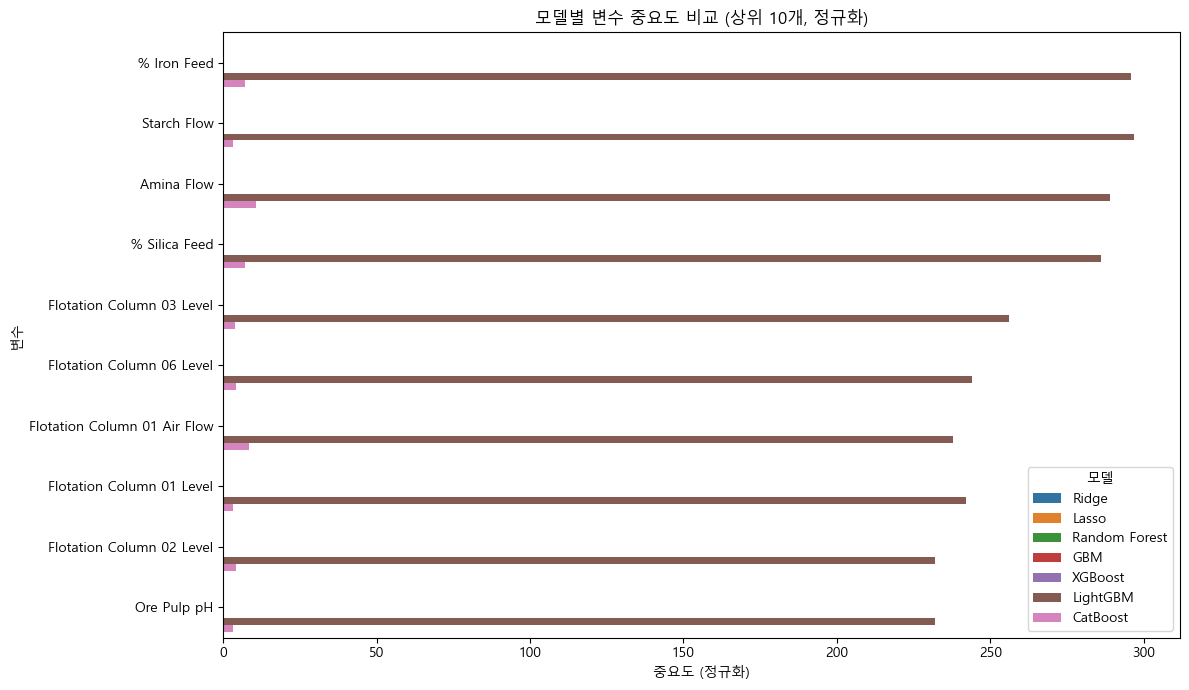

In [41]:
# ── 3) 한눈에 비교 — 상위 10개 막대그래프 ──
top_n = 10
top10 = imp_all.head(top_n)

plot_df = top10.melt(id_vars='변수', value_vars=model_cols,
                     var_name='모델', value_name='중요도')

plt.figure(figsize=(12, 7))
sns.barplot(data=plot_df, y='변수', x='중요도', hue='모델')
plt.title(f'모델별 변수 중요도 비교 (상위 {top_n}개, 정규화)')
plt.xlabel('중요도 (정규화)')
plt.tight_layout()
plt.show()

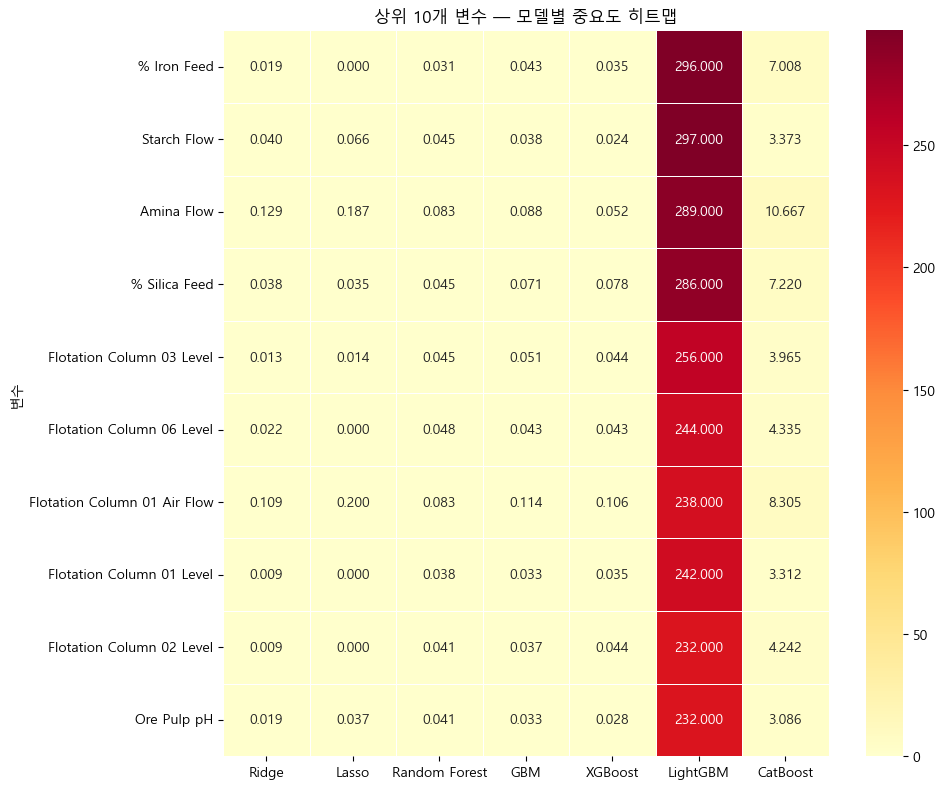

In [42]:
# ── 3-2) 히트맵 비교 ──
plt.figure(figsize=(10, 8))
sns.heatmap(
    top10.set_index('변수')[model_cols],
    annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=0.5,
)
plt.title(f'상위 {top_n}개 변수 — 모델별 중요도 히트맵')
plt.tight_layout()
plt.show()

In [43]:
# ── 4) 핵심 공정 변수 선정 ──
# 기준 1: 평균중요도 상위
# 기준 2: 7개 모델 중 Top-10에 N회 이상 등장

rank_df = imp_all[['변수'] + model_cols].copy()
for col in model_cols:
    rank_df[f'{col}_rank'] = rank_df[col].rank(ascending=False)

rank_cols = [f'{c}_rank' for c in model_cols]
rank_df['Top10_등장횟수'] = (rank_df[model_cols].apply(
    lambda row: sum(row[c] >= rank_df[c].nlargest(top_n).min() for c in model_cols), axis=1
))

# 더 간단한 방법: 각 모델별 top10 변수 집합
top10_sets = {m: set(imp_all.nlargest(top_n, m)['변수']) for m in model_cols}
imp_all['Top10_등장횟수'] = imp_all['변수'].apply(
    lambda v: sum(v in s for s in top10_sets.values())
)

core_vars = imp_all[imp_all['Top10_등장횟수'] >= 5].copy()  # 7개 중 5회 이상
core_vars = core_vars.sort_values('평균중요도', ascending=False)

print("=" * 60)
print("3. 핵심 공정 변수")
print("=" * 60)
print(f"※ 기준: {len(model_cols)}개 모델 중 Top-{top_n}에 5회 이상 등장\n")
display(core_vars[['변수', '평균중요도', 'Top10_등장횟수'] + model_cols].round(4))

print("\n【핵심 변수 요약】")
for i, row in core_vars.iterrows():
    print(f"  • {row['변수']}  (평균중요도={row['평균중요도']:.4f}, "
          f"Top10 등장={int(row['Top10_등장횟수'])}회)")

3. 핵심 공정 변수
※ 기준: 7개 모델 중 Top-10에 5회 이상 등장



,변수,평균중요도,Top10_등장횟수,Ridge,Lasso,Random Forest,GBM,XGBoost,LightGBM,CatBoost
2,Amina Flow,42.8864,7,0.1288,0.1866,0.0830,0.0879,0.0516,289,10.6666
3,% Silica Feed,41.9268,7,0.0384,0.0352,0.0446,0.0706,0.0781,286,7.2204
5,Flotation Column 06 Level,35.4987,5,0.0222,0.0000,0.0476,0.0433,0.0431,244,4.3349
6,Flotation Column 01 Air Flow,35.2738,7,0.1087,0.2002,0.0835,0.1137,0.1057,238,8.3049
14,Flotation Column 04 Air Flow,27.6119,6,0.0869,0.1466,0.0656,0.0682,0.0788,185,7.8371
18,Flotation Column 07 Level,23.7382,5,0.0284,0.0245,0.0571,0.0570,0.0914,161,4.9091
19,Flotation Column 05 Level,23.0988,6,0.0681,0.1043,0.0519,0.0515,0.0731,155,6.3432



【핵심 변수 요약】
  • Amina Flow  (평균중요도=42.8864, Top10 등장=7회)
  • % Silica Feed  (평균중요도=41.9268, Top10 등장=7회)
  • Flotation Column 06 Level  (평균중요도=35.4987, Top10 등장=5회)
  • Flotation Column 01 Air Flow  (평균중요도=35.2738, Top10 등장=7회)
  • Flotation Column 04 Air Flow  (평균중요도=27.6119, Top10 등장=6회)
  • Flotation Column 07 Level  (평균중요도=23.7382, Top10 등장=5회)
  • Flotation Column 05 Level  (평균중요도=23.0988, Top10 등장=6회)


**[과제]** 써니는 가장 우수했던 모델의 성능을 하이퍼파라미터 튜닝으로 더 끌어올리고 싶습니다. AI와 함께 어떤 하이퍼파라미터를 어느 범위까지 탐색하면 좋을지 논의하고 GridSearchCV로 최적의 조합을 찾아 성능을 개선해 보세요.

In [45]:
# ============================================================
# A-4) 하이퍼파라미터 튜닝
# ============================================================
tscv = TimeSeriesSplit(n_splits=5)

# A-3 compare_df에서 최고 모델 확인
best_model_name = compare_df.iloc[0]['model']
print(f"튜닝 대상: {best_model_name}")

튜닝 대상: CatBoost


In [46]:
params_rf = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', None],
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=params_rf,
    cv=tscv, scoring='r2', n_jobs=-1, verbose=1,
)
grid_rf.fit(X_train_tree, Y_train)

print("최적 파라미터:", grid_rf.best_params_)
print("CV R²:", round(grid_rf.best_score_, 4))
best_tuned = grid_rf.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits


KeyboardInterrupt: 

In [ ]:
params_xgb = {
    'n_estimators': [100, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'reg_lambda': [1, 5],
}

grid_xgb = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_grid=params_xgb,
    cv=tscv, scoring='r2', n_jobs=-1, verbose=1,
)
grid_xgb.fit(X_train_tree, Y_train)

print("최적 파라미터:", grid_xgb.best_params_)
print("CV R²:", round(grid_xgb.best_score_, 4))
best_tuned = grid_xgb.best_estimator_

In [ ]:
params_lgbm = {
    'n_estimators': [100, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5],
    'num_leaves': [15, 31],
    'min_child_samples': [20, 50],
    'subsample': [0.8, 1.0],
}

grid_lgbm = GridSearchCV(
    LGBMRegressor(random_state=42, verbose=-1, n_jobs=-1),
    param_grid=params_lgbm,
    cv=tscv, scoring='r2', n_jobs=-1, verbose=1,
)
grid_lgbm.fit(X_train_tree, Y_train)

print("최적 파라미터:", grid_lgbm.best_params_)
print("CV R²:", round(grid_lgbm.best_score_, 4))
best_tuned = grid_lgbm.best_estimator_

In [ ]:
params_cat = {
    'iterations': [100, 300],        # CatBoost는 iterations
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [3, 5],
    'l2_leaf_reg': [1, 3, 5],
}

grid_cat = GridSearchCV(
    CatBoostRegressor(random_state=42, verbose=0),
    param_grid=params_cat,
    cv=tscv, scoring='r2', n_jobs=-1, verbose=1,
)
grid_cat.fit(X_train_tree, Y_train)

print("최적 파라미터:", grid_cat.best_params_)
print("CV R²:", round(grid_cat.best_score_, 4))
best_tuned = grid_cat.best_estimator_

---
# Part B. 분류 태스크 — Steel Plates Faults

## B-0) 데이터 불러오기

**[과제]** 써니는 Day 2에서 사용했던 `dataset/day2_miniproject_cls.csv` 파일을 그대로 불러오려고 합니다. 적절한 변수명으로 데이터프레임을 만들어 보세요.

In [47]:
# 분류용 데이터 불러오기 (Steel Plates Faults)
df_cls = pd.read_csv('dataset/day2_miniproject_cls.csv')

print("데이터 크기 :", df_cls.shape)
df_cls.head()

데이터 크기 : (1941, 34)


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0


---
## B-1) 데이터 탐색 (EDA)

**[과제]** 써니는 오늘도 모델링에 앞서 데이터 상태를 다시 한번 점검하고 싶습니다. AI와 함께 데이터 구조, 결측치, 수집 기간 등 기본적인 특성을 다시 확인해 보세요.

In [48]:
target = 'K_Scatch'

print("=" * 50)
print("1. 데이터 크기")
print("=" * 50)
print("데이터 크기 :", df_cls.shape)
print(f"  → {df_cls.shape[0]:,}개 샘플, {df_cls.shape[1]}개 변수")
df_cls.head()

1. 데이터 크기
데이터 크기 : (1941, 34)
  → 1,941개 샘플, 34개 변수


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0


In [49]:
print("=" * 50)
print("2. 컬럼명 목록")
print("=" * 50)
print(list(df_cls.columns))
print(f"총 {len(df_cls.columns)}개 변수\n")

print("=" * 50)
print("3. 자료형 요약")
print("=" * 50)
df_cls.info()

2. 컬럼명 목록
['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity', 'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer', 'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness', 'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index', 'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index', 'SigmoidOfAreas', 'Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']
총 34개 변수

3. 자료형 요약
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              1941 non-null   int64  
 1   X_Maximum              1941 non-null   int64  
 2   Y_Minimum              1941 non-null   int64  
 3   Y_Maximum              1941 non-

In [50]:
print("=" * 50)
print("4. 기술통계량")
print("=" * 50)
df_cls.describe().T   # 변수를 행으로 → 읽기 쉬움

4. 기술통계량


,count,mean,std,min,25%,50%,75%,max
X_Minimum,1941.0,5.711360e+02,5.206907e+02,0.0000,51.0000,4.350000e+02,1.053000e+03,1.705000e+03
X_Maximum,1941.0,6.179645e+02,4.976274e+02,4.0000,192.0000,4.670000e+02,1.072000e+03,1.713000e+03
Y_Minimum,1941.0,1.650685e+06,1.774578e+06,6712.0000,471253.0000,1.204128e+06,2.183073e+06,1.298766e+07
Y_Maximum,1941.0,1.650739e+06,1.774590e+06,6724.0000,471281.0000,1.204136e+06,2.183084e+06,1.298769e+07
Pixels_Areas,1941.0,1.893878e+03,5.168460e+03,2.0000,84.0000,1.740000e+02,8.220000e+02,1.526550e+05
X_Perimeter,1941.0,1.118552e+02,3.012092e+02,2.0000,15.0000,2.600000e+01,8.400000e+01,1.044900e+04
Y_Perimeter,1941.0,8.296600e+01,4.264829e+02,1.0000,13.0000,2.500000e+01,8.300000e+01,1.815200e+04
Sum_of_Luminosity,1941.0,2.063121e+05,5.122936e+05,250.0000,9522.0000,1.920200e+04,8.301100e+04,1.159141e+07
Minimum_of_Luminosity,1941.0,8.454869e+01,3.213428e+01,0.0000,63.0000,9.000000e+01,1.060000e+02,2.030000e+02
Maximum_of_Luminosity,1941.0,1.301937e+02,1.869099e+01,37.0000,124.0000,1.270000e+02,1.400000e+02,2.530000e+02


In [52]:
print("=" * 50)
print("5. 결측치")
print("=" * 50)
missing = df_cls.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "결측치 없음 ✓")
print("총 결측치 개수 :", missing.sum())

print("\n" + "=" * 50)
print("6. 중복 행")
print("=" * 50)
print("중복 행 개수 :", df_cls.duplicated().sum())

5. 결측치
결측치 없음 ✓
총 결측치 개수 : 0

6. 중복 행
중복 행 개수 : 0


In [57]:
target = 'K_Scatch'
fault_cols = ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']
leak_cols = [c for c in fault_cols if c != target]   # 타겟 외 결함 라벨 → 누수

# 히스토그램·히트맵에 쓸 입력 변수 (27개)
feature_cols = [c for c in df_cls.columns if c not in leak_cols + [target]]
print(f"입력 변수: {len(feature_cols)}개")

입력 변수: 27개


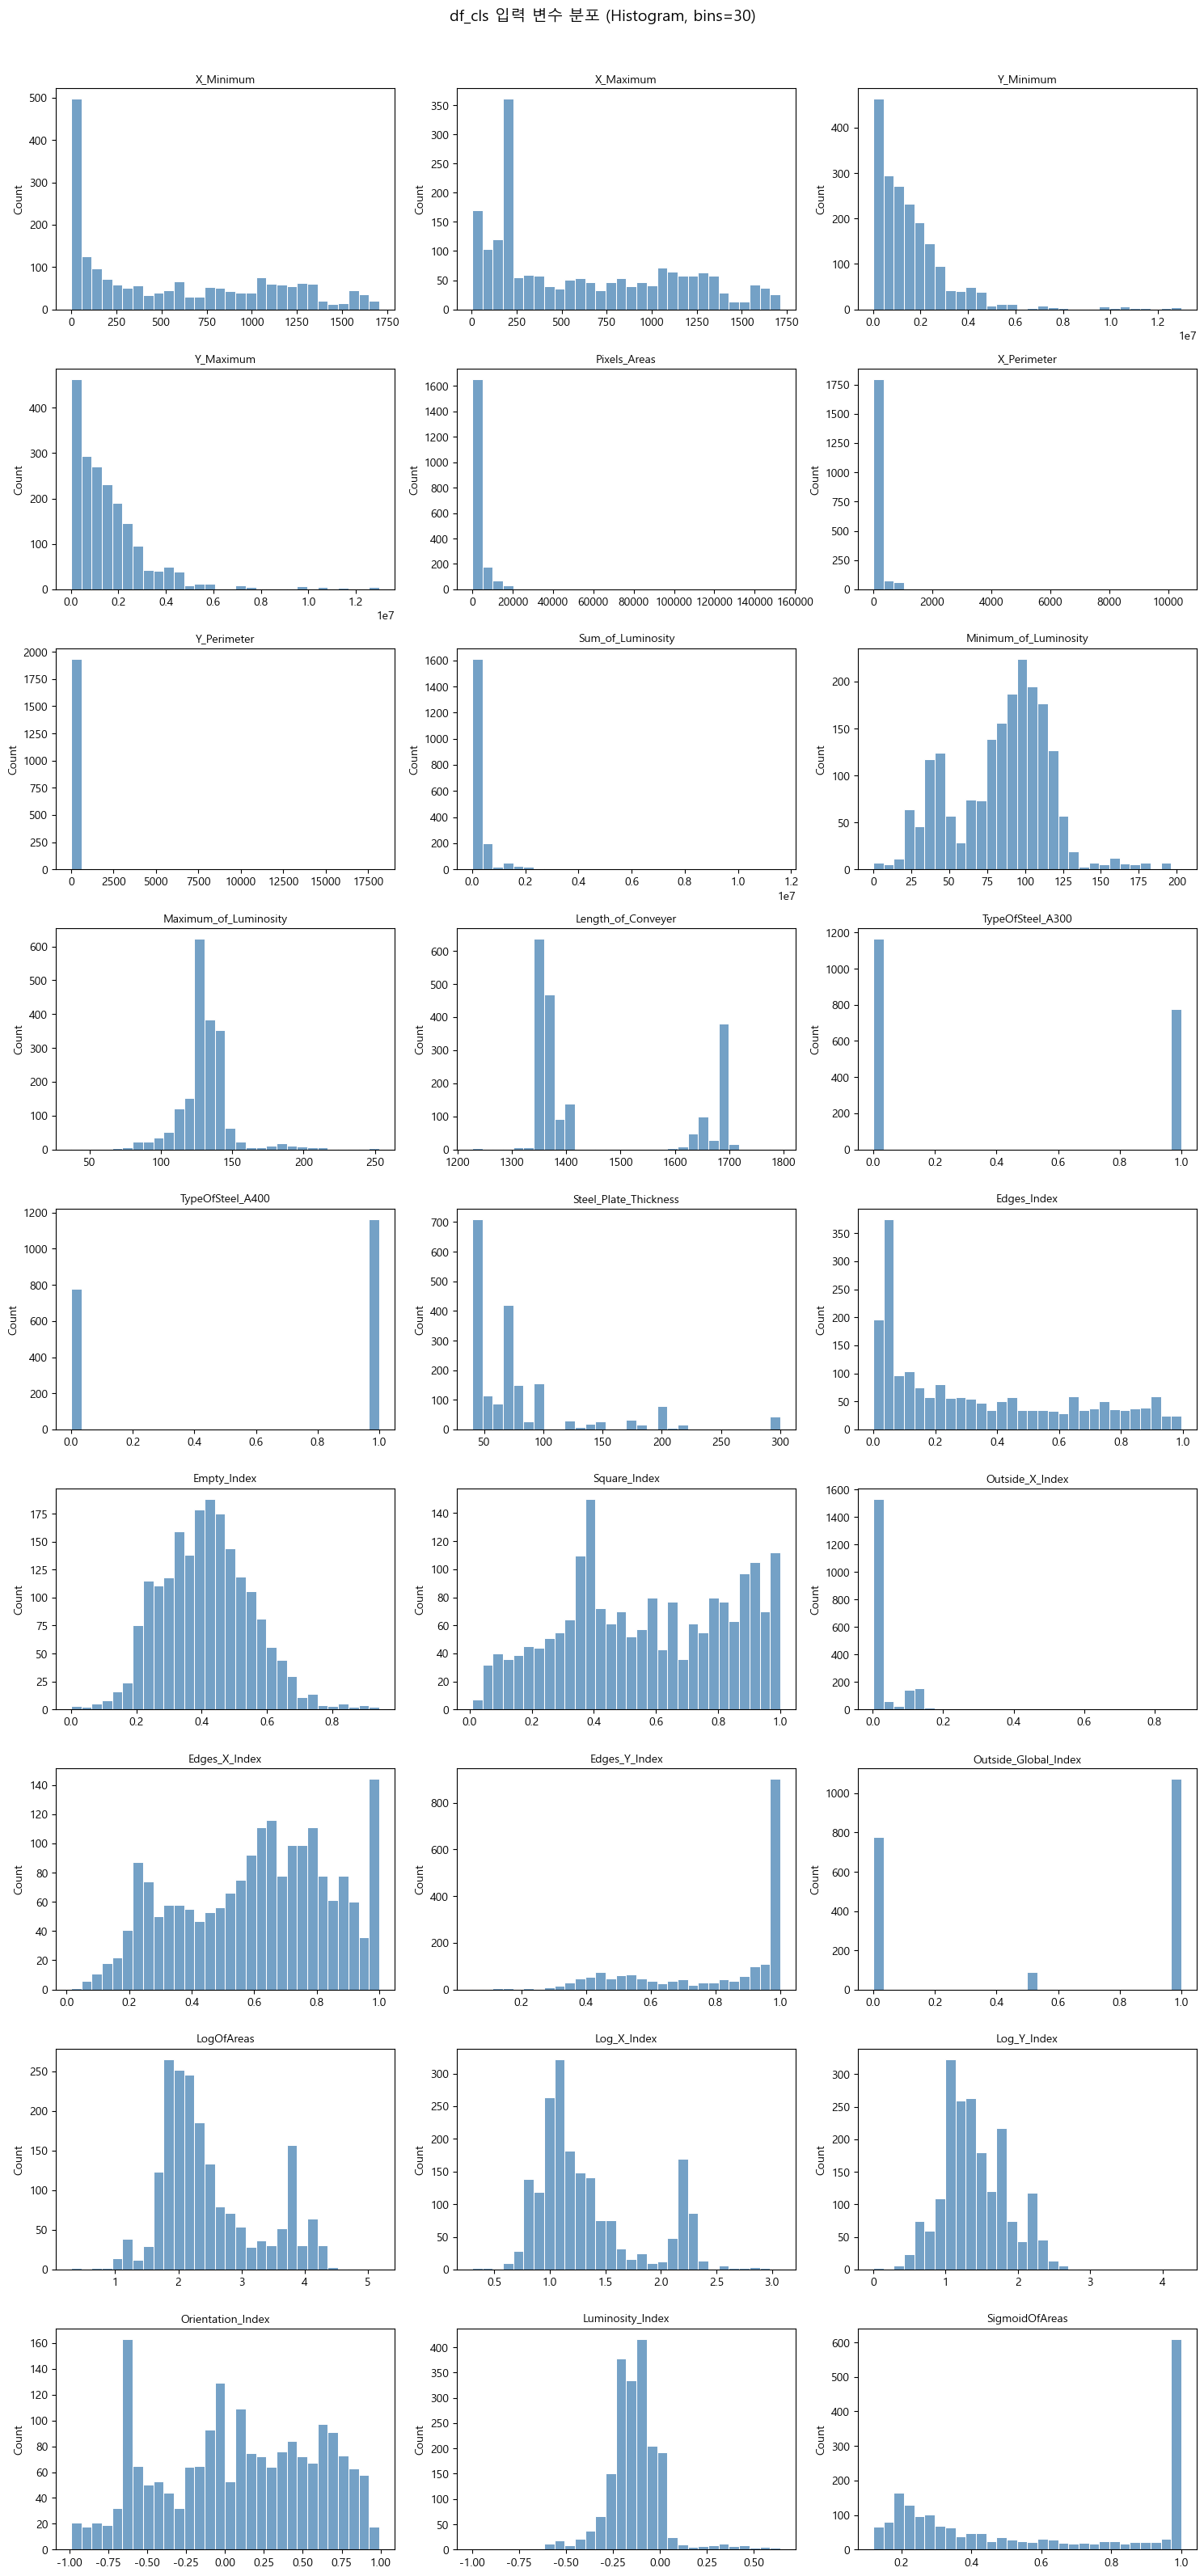

In [58]:
# ===== 1. 입력 변수 분포 히스토그램 (bins=30) =====
n_cols = 3
n_rows = -(-len(feature_cols) // n_cols)   # 올림 나눗셈

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, feature_cols):
    sns.histplot(data=df_cls, x=col, bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')

# 남는 빈 subplot 숨기기
for ax in axes[len(feature_cols):]:
    ax.axis('off')

fig.suptitle('df_cls 입력 변수 분포 (Histogram, bins=30)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

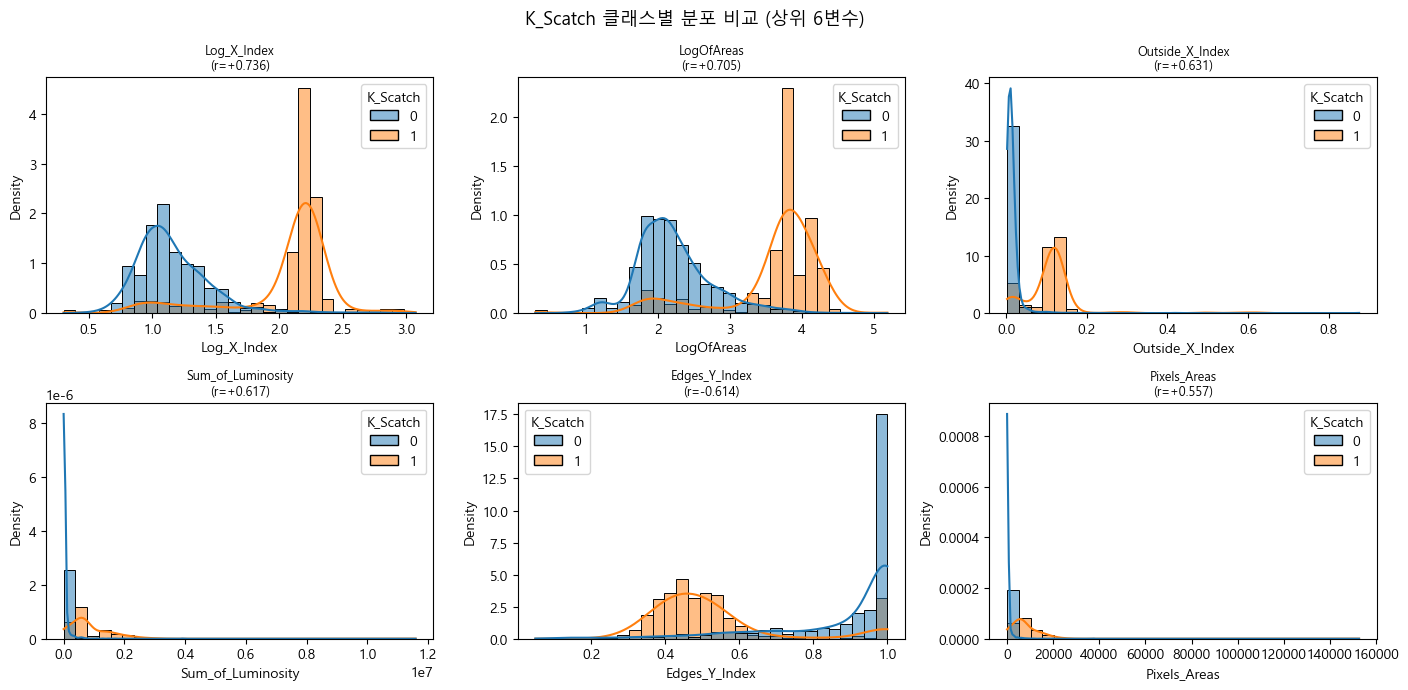

In [59]:
# 타겟과 상관이 높은 변수 상위 6개 (히트맵 전 미리보기용)
corr_preview = df_cls[feature_cols + [target]].corr()[target].drop(target)
top6 = corr_preview.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for ax, col in zip(axes, top6):
    sns.histplot(
        data=df_cls, x=col, hue=target, bins=30,
        stat='density', common_norm=False, kde=True, ax=ax, alpha=0.5
    )
    ax.set_title(f'{col}\n(r={corr_preview[col]:+.3f})', fontsize=9)

fig.suptitle('K_Scatch 클래스별 분포 비교 (상위 6변수)', fontsize=13)
plt.tight_layout()
plt.show()

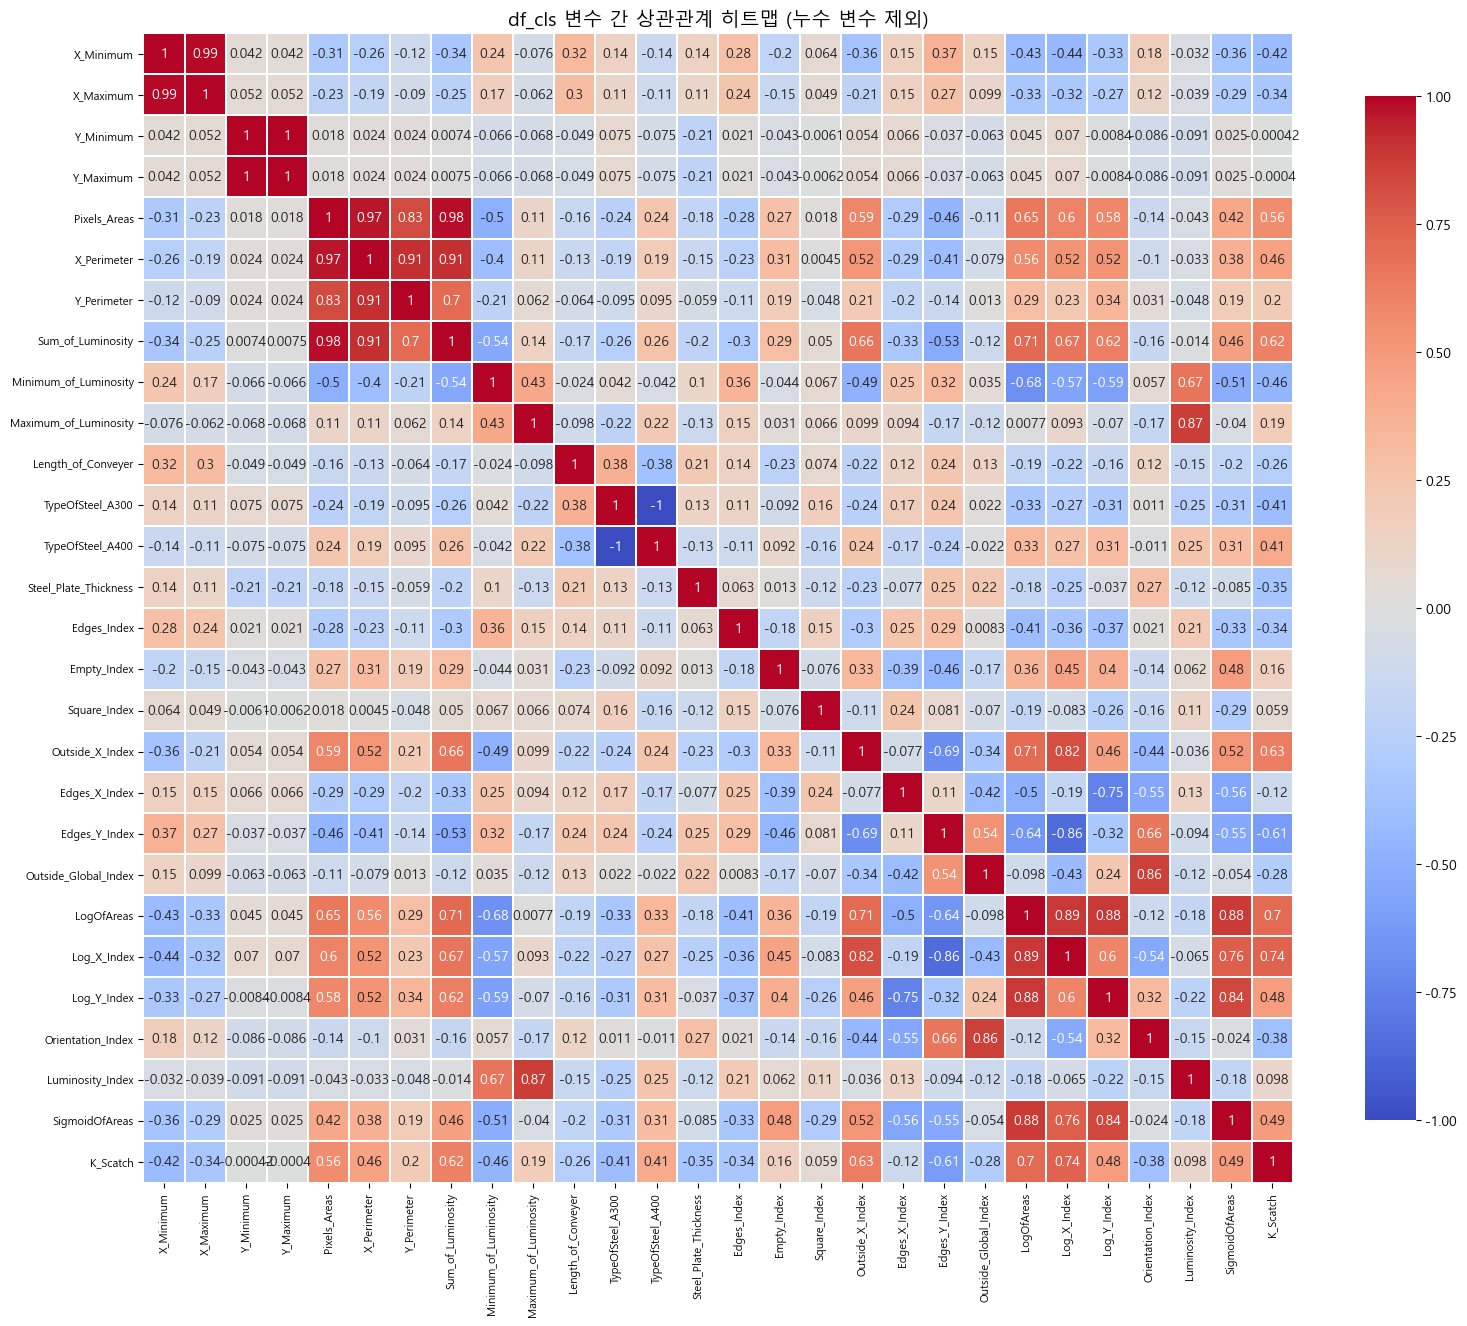

In [61]:
# ===== 2. 상관관계 히트맵 =====
# 입력 변수 + 타겟만 사용 (누수 결함 컬럼 제외)
cols_for_corr = feature_cols + [target]
corr = df_cls[cols_for_corr].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr,
    annot=True,          # 28×28이라 숫자 표시는 생략 (가독성)
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.3,
    cbar_kws={'shrink': 0.8}
)
plt.title('df_cls 변수 간 상관관계 히트맵 (누수 변수 제외)', fontsize=14)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

**[과제]** 써니는 Day 2에서도 확인했던 타겟 변수(K_Scatch)의 클래스 불균형을 앙상블 모델링 전에 다시 한번 점검하려고 합니다. AI와 함께 타겟 변수의 빈도와 비율을 시각화해 보세요.

7. 타겟 변수 [K_Scatch] 분포

[빈도]
K_Scatch
0    1550
1     391
Name: count, dtype: int64

[비율]
K_Scatch
0    0.799
1    0.201
Name: proportion, dtype: float64


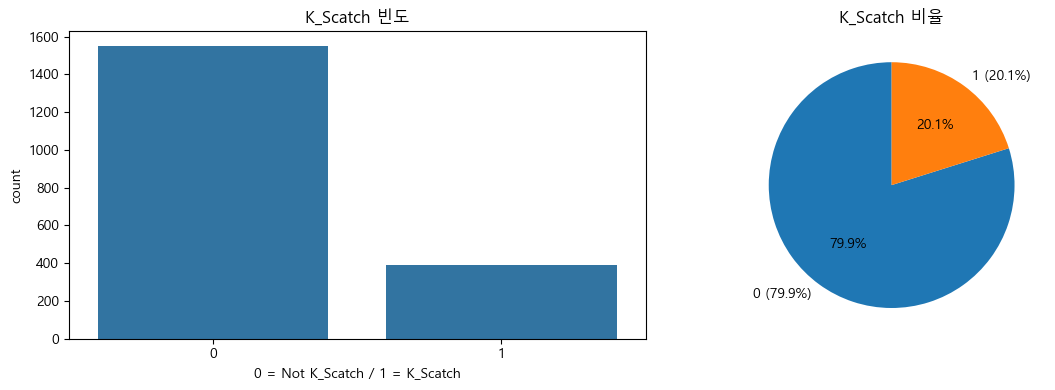


※ K_Scatch=1 비율 약 20% → 클래스 불균형
  → B-2: stratify 분할 / B-3: class_weight 등 고려


In [55]:
print("=" * 50)
print(f"7. 타겟 변수 [{target}] 분포")
print("=" * 50)

print("\n[빈도]")
print(df_cls[target].value_counts())

print("\n[비율]")
print(df_cls[target].value_counts(normalize=True).round(3))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df_cls, x=target, ax=axes[0])
axes[0].set_title(f'{target} 빈도')
axes[0].set_xlabel('0 = Not K_Scatch / 1 = K_Scatch')

ratio = df_cls[target].value_counts(normalize=True)
axes[1].pie(ratio, labels=[f'0 ({ratio[0]:.1%})', f'1 ({ratio[1]:.1%})'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title(f'{target} 비율')

plt.tight_layout()
plt.show()

print(f"\n※ K_Scatch=1 비율 약 20% → 클래스 불균형")
print("  → B-2: stratify 분할 / B-3: class_weight 등 고려")

In [56]:
fault_cols = ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']

print("=" * 50)
print("8. 결함 유형 컬럼 구조")
print("=" * 50)

print("\n[결함 유형별 빈도]")
print(df_cls[fault_cols].sum().sort_values(ascending=False))

print("\n[행당 결함 개수] (1이면 각 행에 결함 1종만 존재)")
print(df_cls[fault_cols].sum(axis=1).value_counts())

print("\n[해석]")
print("  - 각 행은 7개 결함 유형 중 정확히 1개만 1")
print("  - K_Scatch 외 다른 결함 컬럼은 타겟과 배타적")
print("  → B-2에서 누수(leak) 변수로 제거 검토")

8. 결함 유형 컬럼 구조

[결함 유형별 빈도]
Other_Faults    673
Bumps           402
K_Scatch        391
Z_Scratch       190
Pastry          158
Stains           72
Dirtiness        55
dtype: int64

[행당 결함 개수] (1이면 각 행에 결함 1종만 존재)
1    1941
Name: count, dtype: int64

[해석]
  - 각 행은 7개 결함 유형 중 정확히 1개만 1
  - K_Scatch 외 다른 결함 컬럼은 타겟과 배타적
  → B-2에서 누수(leak) 변수로 제거 검토


In [63]:
fault_cols = ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']

# 각 행의 결함 개수 (0, 1, 2, ... 중 몇 개가 1인지)
fault_count_per_row = df_cls[fault_cols].sum(axis=1)

print("=" * 50)
print("【행당 결함 개수 분포】")
print("=" * 50)
print(fault_count_per_row.value_counts().sort_index())

# 검증
if (fault_count_per_row == 1).all():
    print("\n✓ 모든 행에 결함이 정확히 1종류씩만 있습니다.")
else:
    print(f"\n✗ 문제 행 {(fault_count_per_row != 1).sum()}개 발견")

【행당 결함 개수 분포】
1    1941
Name: count, dtype: int64

✓ 모든 행에 결함이 정확히 1종류씩만 있습니다.


In [64]:
# 결함이 0개이거나 2개 이상인 행
invalid_rows = df_cls[fault_count_per_row != 1]

if len(invalid_rows) == 0:
    print("문제 행 없음 ✓")
else:
    print(f"문제 행 {len(invalid_rows)}개:")
    display(invalid_rows[fault_cols])

문제 행 없음 ✓


---
## B-2) 데이터 전처리

### B-2-1) 타겟 변수 정의

**[과제]** 써니는 K_Scatch를 분류 타겟(0/1)으로 사용하여 모델을 만들려고 합니다. 그런데 다른 결함 유형 변수들이 예측에 어떤 영향을 주는지 궁금해졌습니다. AI와 함께 각 결함 변수와 K_Scatch의 관계를 분석하고, 실제 공정 특성을 학습하기보다 정답을 미리 알려주는 역할을 하는 변수가 있는지 탐색해 보세요. 이후 이러한 변수들을 어떻게 처리하는 것이 적절할지 고민하고 적절한 전처리 방법을 적용해보세요.

【타겟 K_Scatch 상관 상위 10】
Log_X_Index              0.736
LogOfAreas               0.705
Outside_X_Index          0.631
Sum_of_Luminosity        0.617
Edges_Y_Index           -0.614
Pixels_Areas             0.557
SigmoidOfAreas           0.489
Log_Y_Index              0.482
Minimum_of_Luminosity   -0.461
X_Perimeter              0.455
Name: K_Scatch, dtype: float64


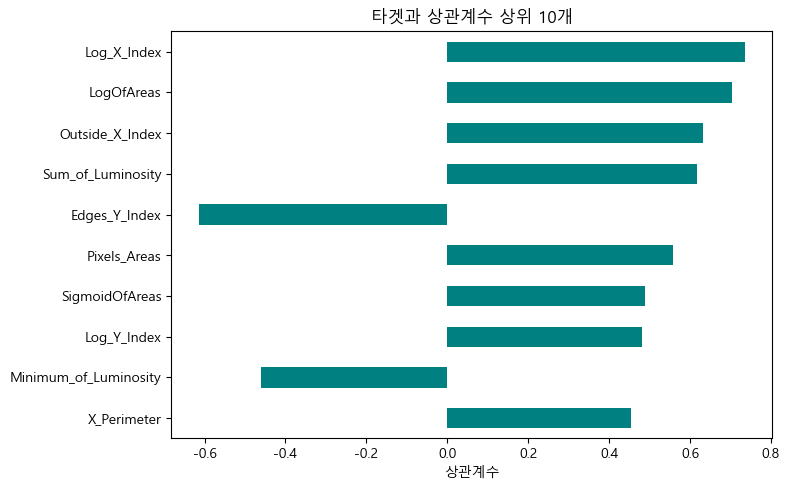


【|r| ≥ 0.8 변수쌍: 16개】
  TypeOfSteel_A300 ↔ TypeOfSteel_A400 : r = -1.000
  Y_Minimum ↔ Y_Maximum : r = +1.000
  X_Minimum ↔ X_Maximum : r = +0.988
  Pixels_Areas ↔ Sum_of_Luminosity : r = +0.979
  Pixels_Areas ↔ X_Perimeter : r = +0.967
  X_Perimeter ↔ Sum_of_Luminosity : r = +0.913
  X_Perimeter ↔ Y_Perimeter : r = +0.912
  LogOfAreas ↔ Log_X_Index : r = +0.889
  LogOfAreas ↔ Log_Y_Index : r = +0.883
  LogOfAreas ↔ SigmoidOfAreas : r = +0.878
  Maximum_of_Luminosity ↔ Luminosity_Index : r = +0.870
  Outside_Global_Index ↔ Orientation_Index : r = +0.863
  Edges_Y_Index ↔ Log_X_Index : r = -0.855
  Log_Y_Index ↔ SigmoidOfAreas : r = +0.838
  Pixels_Areas ↔ Y_Perimeter : r = +0.827
  Outside_X_Index ↔ Log_X_Index : r = +0.820


In [65]:
# ===== 3. 타겟과의 상관계수 (절댓값 순) =====
target_corr = corr[target].drop(target).sort_values(key=abs, ascending=False)

print("【타겟 K_Scatch 상관 상위 10】")
print(target_corr.head(10).round(3))

plt.figure(figsize=(8, 5))
target_corr.head(10).plot(kind='barh', color='teal')
plt.title('타겟과 상관계수 상위 10개')
plt.xlabel('상관계수')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ===== 4. |r| ≥ 0.8 강한 변수쌍 =====
threshold = 0.8
corr_pairs = corr.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0].drop_duplicates()
high_pairs = corr_pairs[corr_pairs >= threshold].sort_values(ascending=False)

print(f"\n【|r| ≥ {threshold} 변수쌍: {len(high_pairs)}개】")
for (var1, var2), abs_r in high_pairs.items():
    r = corr.loc[var1, var2]
    print(f"  {var1} ↔ {var2} : r = {r:+.3f}")

In [66]:
target = 'K_Scatch'
fault_cols = ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']
leak_cols = [c for c in fault_cols if c != target]   # 타겟 외 6개 결함 라벨

print("=" * 60)
print("【1】 행당 결함 개수 (배타성 확인)")
print("=" * 60)
fault_sum = df_cls[fault_cols].sum(axis=1)
print(fault_sum.value_counts().sort_index())
print(f"→ 모든 행 합계=1: {(fault_sum == 1).all()}")

【1】 행당 결함 개수 (배타성 확인)
1    1941
Name: count, dtype: int64
→ 모든 행 합계=1: True


In [68]:
print("\n" + "=" * 60)
print("【2】 결함 변수 vs K_Scatch 교차표")
print("=" * 60)

leak_summary = []

for col in leak_cols:
    ct = pd.crosstab(df_cls[col], df_cls[target], margins=True)
    print(f"\n--- {col} ---")
    print(ct)

    # col=1일 때 K_Scatch가 항상 0인지 확인
    when_one = df_cls.loc[df_cls[col] == 1, target]
    k_when_one = when_one.sum()          # K=1인 개수 (0이어야 정상)
    n_when_one = len(when_one)

  # col=0일 때만 K=1이 나올 수 있음
    leak_summary.append({
        '결함변수': col,
        f'{col}=1 샘플수': n_when_one,
        f'{col}=1일 때 K=1': k_when_one,
        '누수 여부': '누수 ✗' if k_when_one == 0 else '이상 ⚠'
    })



【2】 결함 변수 vs K_Scatch 교차표

--- Pastry ---
K_Scatch     0    1   All
Pastry                   
0         1392  391  1783
1          158    0   158
All       1550  391  1941

--- Z_Scratch ---
K_Scatch      0    1   All
Z_Scratch                 
0          1360  391  1751
1           190    0   190
All        1550  391  1941

--- Stains ---
K_Scatch     0    1   All
Stains                   
0         1478  391  1869
1           72    0    72
All       1550  391  1941

--- Dirtiness ---
K_Scatch      0    1   All
Dirtiness                 
0          1495  391  1886
1            55    0    55
All        1550  391  1941

--- Bumps ---
K_Scatch     0    1   All
Bumps                    
0         1148  391  1539
1          402    0   402
All       1550  391  1941

--- Other_Faults ---
K_Scatch         0    1   All
Other_Faults                 
0              877  391  1268
1              673    0   673
All           1550  391  1941


In [70]:
print("\n" + "=" * 60)
print("【4】 누수 규칙 검증")
print("=" * 60)

# 규칙: 다른 결함 중 하나라도 1이면 → K_Scatch = 0
rule_pred = (df_cls[leak_cols].sum(axis=1) == 0).astype(int)   # 결함 없으면 K 후보만 남음

# 실제로 K=1인 행은 반드시 다른 결함이 모두 0
print("K_Scatch=1인데 다른 결함도 1인 행:",
      ((df_cls[target] == 1) & (df_cls[leak_cols].sum(axis=1) > 0)).sum())

print("다른 결함=1인데 K_Scatch=1인 행:",
      ((df_cls[leak_cols].sum(axis=1) > 0) & (df_cls[target] == 1)).sum())

print("\n※ 위 두 값이 모두 0이면 → 결함 라벨만으로 타겟을 거의 완벽히 추론 가능")
print("  → 모델링 입력에서 반드시 제거 (데이터 누수)")


【4】 누수 규칙 검증
K_Scatch=1인데 다른 결함도 1인 행: 0
다른 결함=1인데 K_Scatch=1인 행: 0

※ 위 두 값이 모두 0이면 → 결함 라벨만으로 타겟을 거의 완벽히 추론 가능
  → 모델링 입력에서 반드시 제거 (데이터 누수)


In [72]:
def find_mc_drop_cols(df, target, leakage_cols, threshold=0.8):
    """
    |r| >= threshold 인 변수 쌍을 찾고,
    각 쌍에서 타겟과 상관이 낮은 변수를 제거 대상으로 선정
  """
    feature_cols = [c for c in df.columns if c not in leakage_cols + [target]]
    corr = df[feature_cols + [target]].corr()

    corr_pairs = corr.abs().unstack()
    corr_pairs = corr_pairs[corr_pairs < 1.0].drop_duplicates()
    high_pairs = corr_pairs[corr_pairs >= threshold].sort_values(ascending=False)

    target_corr = corr[target].drop(target).abs()

    to_drop = set()
    for (var1, var2), abs_r in high_pairs.items():
        if var1 in to_drop or var2 in to_drop:
            continue
        if var1 == target or var2 == target:
            continue
        drop_var = var1 if target_corr.get(var1, 0) < target_corr.get(var2, 0) else var2
        to_drop.add(drop_var)

    return sorted(to_drop), high_pairs, feature_cols, corr


# ── Step 1: 누수 변수 제거 ──
print("=" * 60)
print("【Step 1】 데이터 누수 변수 제거")
print("=" * 60)
print("제거 대상 (leak_cols):", leak_cols)
print("이유: 각 행에 결함 1종만 존재 → 타겟과 배타적")

# ── Step 2: 다중공선성 제거 (|r| >= 0.8) ──
threshold = 0.8
mc_drop_cols, high_pairs, feature_cols, corr = find_mc_drop_cols(
    df_cls, target, leak_cols, threshold=threshold
)

print("\n" + "=" * 60)
print(f"【Step 2】 다중공선성 제거 (|r| >= {threshold})")
print("=" * 60)
print(f"강한 상관쌍: {len(high_pairs)}개\n")

for (var1, var2), abs_r in high_pairs.items():
    r = corr.loc[var1, var2]
    drop_var = var1 if corr[target].abs().get(var1, 0) < corr[target].abs().get(var2, 0) else var2
    print(f"  {var1} ↔ {var2} : r={r:+.3f}  → 제거: {drop_var}")

print(f"\n다중공선성 제거 변수 ({len(mc_drop_cols)}개):")
print(mc_drop_cols)

【Step 1】 데이터 누수 변수 제거
제거 대상 (leak_cols): ['Pastry', 'Z_Scratch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']
이유: 각 행에 결함 1종만 존재 → 타겟과 배타적

【Step 2】 다중공선성 제거 (|r| >= 0.8)
강한 상관쌍: 16개

  TypeOfSteel_A300 ↔ TypeOfSteel_A400 : r=-1.000  → 제거: TypeOfSteel_A300
  Y_Minimum ↔ Y_Maximum : r=+1.000  → 제거: Y_Maximum
  X_Minimum ↔ X_Maximum : r=+0.988  → 제거: X_Maximum
  Pixels_Areas ↔ Sum_of_Luminosity : r=+0.979  → 제거: Pixels_Areas
  Pixels_Areas ↔ X_Perimeter : r=+0.967  → 제거: X_Perimeter
  X_Perimeter ↔ Sum_of_Luminosity : r=+0.913  → 제거: X_Perimeter
  X_Perimeter ↔ Y_Perimeter : r=+0.912  → 제거: Y_Perimeter
  LogOfAreas ↔ Log_X_Index : r=+0.889  → 제거: LogOfAreas
  LogOfAreas ↔ Log_Y_Index : r=+0.883  → 제거: Log_Y_Index
  LogOfAreas ↔ SigmoidOfAreas : r=+0.878  → 제거: SigmoidOfAreas
  Maximum_of_Luminosity ↔ Luminosity_Index : r=+0.870  → 제거: Luminosity_Index
  Outside_Global_Index ↔ Orientation_Index : r=+0.863  → 제거: Outside_Global_Index
  Edges_Y_Index ↔ Log_X_Index : r=-0.855  → 제거: Edges

In [73]:
# 최종 feature = 누수 제거 후 feature_cols - mc_drop_cols
feat_final = [c for c in feature_cols if c not in mc_drop_cols]

print("\n" + "=" * 60)
print("【최종 변수 정리】")
print("=" * 60)
print(f"원본 변수          : {df_cls.shape[1]}개")
print(f"누수 제거 후       : {len(feature_cols)}개")
print(f"다중공선성 제거 후 : {len(feat_final)}개")
print(f"\n최종 입력 변수 ({len(feat_final)}개):")
print(feat_final)

# X, y 정의
y = df_cls[target].astype(int)
X = df_cls[feat_final]

print(f"\nX shape: {X.shape},  y 분포:\n{y.value_counts(normalize=True).round(3)}")


【최종 변수 정리】
원본 변수          : 34개
누수 제거 후       : 27개
다중공선성 제거 후 : 16개

최종 입력 변수 (16개):
['X_Minimum', 'Y_Minimum', 'Y_Perimeter', 'Sum_of_Luminosity', 'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer', 'TypeOfSteel_A400', 'Steel_Plate_Thickness', 'Edges_Index', 'Empty_Index', 'Square_Index', 'Edges_X_Index', 'Log_X_Index', 'Orientation_Index', 'SigmoidOfAreas']

X shape: (1941, 16),  y 분포:
K_Scatch
0    0.799
1    0.201
Name: proportion, dtype: float64


In [74]:
remain_corr = X.corr().abs().unstack()
remain_corr = remain_corr[remain_corr < 1.0].drop_duplicates()
print(f"제거 후 남은 변수 간 최대 |r|: {remain_corr.max():.3f}")
print(f"|r| >= {threshold} 쌍 개수: {(remain_corr >= threshold).sum()}개")

제거 후 남은 변수 간 최대 |r|: 0.757
|r| >= 0.8 쌍 개수: 0개


### B-2-2) 결측치 확인 및 데이터 분할

**[과제]** 써니는 데이터셋에 존재하는 클래스 불균형이 모델 학습과 평가에 영향을 줄 수 있다고 생각했습니다. AI와 함께 타겟 변수의 분포를 확인하고 원본 데이터의 클래스 비율이 학습 데이터와 테스트 데이터에도 유지될 수 있도록 적절한 데이터 분할 방법을 적용해 보세요.

In [76]:
print("=" * 50)
print("【2】 결측치 확인")
print("=" * 50)

missing = X.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "결측치 없음 ✓")
print("총 결측치 개수 :", missing.sum())

【2】 결측치 확인
결측치 없음 ✓
총 결측치 개수 : 0


In [77]:
print("=" * 50)
print("【3】 층화 분할 (stratified split)")
print("=" * 50)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% 학습 / 20% 테스트
    random_state=42,     # 재현 가능한 분할
    stratify=y           # 원본 클래스 비율 유지
)

print("학습 데이터 크기   :", X_train.shape)
print("테스트 데이터 크기 :", X_test.shape)

【3】 층화 분할 (stratified split)
학습 데이터 크기   : (1552, 16)
테스트 데이터 크기 : (389, 16)


In [78]:
print("\n" + "=" * 50)
print("【4】 분할 후 클래스 비율 비교")
print("=" * 50)

def show_ratio(name, y_data):
    ratio = y_data.value_counts(normalize=True)
    count = y_data.value_counts()
    print(f"\n[{name}]")
    print(f"  0: {count[0]:4d}개 ({ratio[0]:.2%})")
    print(f"  1: {count[1]:4d}개 ({ratio[1]:.2%})")

show_ratio("원본", y)
show_ratio("학습", y_train)
show_ratio("테스트", y_test)

# 비율 비교표
ratio_compare = pd.DataFrame({
    '원본':   y.value_counts(normalize=True),
    '학습':   y_train.value_counts(normalize=True),
    '테스트': y_test.value_counts(normalize=True),
}).round(4)
display(ratio_compare)


【4】 분할 후 클래스 비율 비교

[원본]
  0: 1550개 (79.86%)
  1:  391개 (20.14%)

[학습]
  0: 1239개 (79.83%)
  1:  313개 (20.17%)

[테스트]
  0:  311개 (79.95%)
  1:   78개 (20.05%)


,원본,학습,테스트
K_Scatch,,,
0,0.7986,0.7983,0.7995
1,0.2014,0.2017,0.2005


### B-2-3) 스케일링/인코딩 필요 여부 검토

**[과제]** 써니는 Day 2에서 로지스틱 회귀 모델 학습을 위해 스케일링을 적용했었습니다. 이번에 사용할 앙상블 모델들도 동일한 전처리가 필요한지 궁금해졌습니다. AI와 함께 모델별 특성을 살펴보고 스케일링과 인코딩이 필요한지 판단하여 적절한 전처리를 적용해 보세요.

In [79]:
print("=" * 50)
print("【1】 변수 유형 확인")
print("=" * 50)

print("\n[자료형]")
print(X_train.dtypes.value_counts())

print("\n[변수 목록]")
print(X_train.columns.tolist())

# 이진 지시변수 (0/1) — 스케일링 제외
binary_cols = [c for c in X_train.columns if X_train[c].nunique() == 2
               and set(X_train[c].unique()).issubset({0, 1})]
num_cols = [c for c in X_train.columns if c not in binary_cols]

print(f"\n수치형 (스케일링 대상) : {len(num_cols)}개")
print(num_cols)
print(f"이진 지시변수 (스케일링 제외) : {len(binary_cols)}개")
print(binary_cols)

# 문자열 범주형 확인
obj_cols = X_train.select_dtypes(include='object').columns.tolist()
print(f"문자열 범주형 (인코딩 필요) : {obj_cols if obj_cols else '없음 ✓'}")

【1】 변수 유형 확인

[자료형]
int64      9
float64    7
Name: count, dtype: int64

[변수 목록]
['X_Minimum', 'Y_Minimum', 'Y_Perimeter', 'Sum_of_Luminosity', 'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer', 'TypeOfSteel_A400', 'Steel_Plate_Thickness', 'Edges_Index', 'Empty_Index', 'Square_Index', 'Edges_X_Index', 'Log_X_Index', 'Orientation_Index', 'SigmoidOfAreas']

수치형 (스케일링 대상) : 15개
['X_Minimum', 'Y_Minimum', 'Y_Perimeter', 'Sum_of_Luminosity', 'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer', 'Steel_Plate_Thickness', 'Edges_Index', 'Empty_Index', 'Square_Index', 'Edges_X_Index', 'Log_X_Index', 'Orientation_Index', 'SigmoidOfAreas']
이진 지시변수 (스케일링 제외) : 1개
['TypeOfSteel_A400']
문자열 범주형 (인코딩 필요) : 없음 ✓


In [80]:
print("=" * 50)
print("【2】 로지스틱 회귀용 StandardScaler")
print("=" * 50)

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

# 수치형만 스케일링 (이진 지시변수는 0/1 유지)
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test[num_cols])

print("스케일링 완료")
print(f"  수치형 {len(num_cols)}개 스케일링 / 이진 {len(binary_cols)}개 유지")
print(f"  X_train_scaled : {X_train_scaled.shape}")
print(f"  X_test_scaled  : {X_test_scaled.shape}")

# 스케일링 전후 비교 (샘플)
print("\n[스케일링 전 — Log_X_Index]")
print(f"  mean={X_train['Log_X_Index'].mean():.2f}, std={X_train['Log_X_Index'].std():.2f}")
print("[스케일링 후 — Log_X_Index]")
print(f"  mean={X_train_scaled['Log_X_Index'].mean():.4f}, std={X_train_scaled['Log_X_Index'].std():.4f}")

X_train_scaled.head()

【2】 로지스틱 회귀용 StandardScaler
스케일링 완료
  수치형 15개 스케일링 / 이진 1개 유지
  X_train_scaled : (1552, 16)
  X_test_scaled  : (389, 16)

[스케일링 전 — Log_X_Index]
  mean=1.34, std=0.49
[스케일링 후 — Log_X_Index]
  mean=0.0000, std=1.0003


,X_Minimum,Y_Minimum,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A400,Steel_Plate_Thickness,Edges_Index,Empty_Index,Square_Index,Edges_X_Index,Log_X_Index,Orientation_Index,SigmoidOfAreas
1746,0.649445,-0.747472,-0.161215,-0.390715,-0.161730,-1.470971,-0.700744,0,3.978011,1.063970,-0.103967,1.200379,0.574630,-0.792592,0.031630,-1.150533
1734,-1.076665,-0.246836,-0.135904,-0.372065,-0.069120,-0.325723,-0.596403,1,-0.704050,-1.053090,-0.148260,-0.176972,0.966672,-0.612980,0.783150,-0.595668
1812,0.088747,0.215120,-0.142232,-0.374246,1.227424,0.559241,-0.700744,1,-0.704050,1.951997,2.454901,-0.607166,0.074481,0.342139,-1.354348,0.282672
341,1.215885,-0.437934,-0.102156,-0.371695,1.042203,0.246900,-0.672919,1,1.727020,-0.369065,0.977235,-1.420324,-1.669107,-1.017314,1.461556,-0.428913
638,-1.019255,0.173981,0.096114,0.961866,-1.303923,-0.221610,-0.700744,1,-0.704050,-0.904695,-0.122120,-0.729451,0.271114,1.872347,-1.420870,1.224173


In [81]:
print("=" * 50)
print("【3】 트리 기반 앙상블 — 스케일링 불필요")
print("=" * 50)
print("""
[판단] Random Forest, GBM, XGBoost, LightGBM, CatBoost
  → 스케일링 불필요

[이유]
  1) 분할 기준: "변수 값 > 임계값"
  2) 스케일링은 단조 변환 → 분할 결과 동일
  3) 성능 차이 거의 없음, 해석만 어려워짐

[사용 데이터]
  → X_train, X_test (원본) 그대로
""")

# 앙상블용 변수명 (Part A와 동일하게 구분)
X_train_tree = X_train.copy()
X_test_tree  = X_test.copy()

print(f"앙상블 모델 입력 shape : {X_train_tree.shape}, {X_test_tree.shape}")

【3】 트리 기반 앙상블 — 스케일링 불필요

[판단] Random Forest, GBM, XGBoost, LightGBM, CatBoost
  → 스케일링 불필요

[이유]
  1) 분할 기준: "변수 값 > 임계값"
  2) 스케일링은 단조 변환 → 분할 결과 동일
  3) 성능 차이 거의 없음, 해석만 어려워짐

[사용 데이터]
  → X_train, X_test (원본) 그대로

앙상블 모델 입력 shape : (1552, 16), (389, 16)


In [82]:
print("=" * 50)
print("【4】 모델별 입력 데이터 정리")
print("=" * 50)

preprocess_summary = pd.DataFrame({
    '모델': ['Logistic Regression', 'Random Forest', 'GBM',
             'XGBoost', 'LightGBM', 'CatBoost'],
    '학습 데이터': ['X_train_scaled'] * 1 + ['X_train_tree'] * 5,
    '테스트 데이터': ['X_test_scaled'] * 1 + ['X_test_tree'] * 5,
    '스케일링': ['O (StandardScaler)'] + ['X (불필요)'] * 5,
    '인코딩': ['불필요 (전부 수치형)'] * 6,
})
display(preprocess_summary)

【4】 모델별 입력 데이터 정리


,모델,학습 데이터,테스트 데이터,스케일링,인코딩
0,Logistic Regression,X_train_scaled,X_test_scaled,O (StandardScaler),불필요 (전부 수치형)
1,Random Forest,X_train_tree,X_test_tree,X (불필요),불필요 (전부 수치형)
2,GBM,X_train_tree,X_test_tree,X (불필요),불필요 (전부 수치형)
3,XGBoost,X_train_tree,X_test_tree,X (불필요),불필요 (전부 수치형)
4,LightGBM,X_train_tree,X_test_tree,X (불필요),불필요 (전부 수치형)
5,CatBoost,X_train_tree,X_test_tree,X (불필요),불필요 (전부 수치형)


---
## B-3) 모델 학습 및 예측

**[과제]** 써니는 Day 2에서 학습한 회귀 모델과 Day 3에서 학습한 앙상블 모델을 동일한 데이터셋에 적용하여 성능을 비교해 보고자 합니다. AI와 함께 모델 학습, 예측, 성능 평가 코드를 작성하고, 여러 모델의 결과를 한눈에 비교할 수 있는 방법을 찾아 성능을 비교 및 분석해 보세요.

In [ ]:
def eval_cls(model, X_tr, y_tr, X_te, y_te, name=""):
    """
    분류 모델 학습 + 테스트 성능 반환
    - Accuracy  : 전체 정확도
    - Precision : 양성(1) 예측 중 실제 양성 비율
    - Recall    : 실제 양성 중 맞게 찾은 비율 (소수 클래스 탐지)
    - F1        : Precision과 Recall의 조화평균 (불균형 데이터에 유용)
    """
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)

    acc  = accuracy_score(y_te, pred)
    prec = precision_score(y_te, pred, zero_division=0)
    rec  = recall_score(y_te, pred, zero_division=0)
    f1   = f1_score(y_te, pred, zero_division=0)

    print(f"[{name}]")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-score  : {f1:.4f}")
    print()

    return {
        "model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "fitted": model,
        "pred": pred,
    }

results_cls = []   # 모든 분류 모델 결과 저장

In [85]:
from sklearn.linear_model import LogisticRegression

# ============================================================
# 1. Logistic Regression — StandardScaler 적용 데이터
# ============================================================
logit = LogisticRegression(max_iter=1000, random_state=42)

results_cls.append(
    eval_cls(logit, X_train_scaled, y_train, X_test_scaled, y_test, "Logistic Regression")
)

[Logistic Regression]
  Accuracy  : 0.9640
  Precision : 0.9211
  Recall    : 0.8974
  F1-score  : 0.9091



In [86]:
# ============================================================
# 2. 트리 기반 앙상블 — 원본 데이터 (스케일링 X)
# ============================================================
X_tr = X_train_tree
X_te = X_test_tree

# --- Random Forest ---
rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
results_cls.append(eval_cls(rf, X_tr, y_train, X_te, y_test, "Random Forest"))

# --- GBM (sklearn) ---
gbm = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
)
results_cls.append(eval_cls(gbm, X_tr, y_train, X_te, y_test, "GBM"))

# --- XGBoost ---
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
)
results_cls.append(eval_cls(xgb, X_tr, y_train, X_te, y_test, "XGBoost"))

# --- LightGBM ---
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    verbose=-1,
    n_jobs=-1,
)
results_cls.append(eval_cls(lgbm, X_tr, y_train, X_te, y_test, "LightGBM"))

# --- CatBoost ---
cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=5,
    random_state=42,
    verbose=0,
)
results_cls.append(eval_cls(cat, X_tr, y_train, X_te, y_test, "CatBoost"))

[Random Forest]
  Accuracy  : 0.9949
  Precision : 1.0000
  Recall    : 0.9744
  F1-score  : 0.9870

[GBM]
  Accuracy  : 0.9949
  Precision : 1.0000
  Recall    : 0.9744
  F1-score  : 0.9870

[XGBoost]
  Accuracy  : 0.9949
  Precision : 1.0000
  Recall    : 0.9744
  F1-score  : 0.9870

[LightGBM]
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-score  : 1.0000

[CatBoost]
  Accuracy  : 0.9974
  Precision : 1.0000
  Recall    : 0.9872
  F1-score  : 0.9935



### 데이터 누수 점검 (F1이 높을 때)

테스트 F1이 0.98~1.0으로 나오면 **결함 라벨 누수**를 의심할 수 있습니다. 아래 체크리스트로 현재 파이프라인을 검증합니다.

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

print("=" * 60)
print("【데이터 누수 점검】")
print("=" * 60)

# 1) 입력 X에 결함 라벨·타겟이 섞여 있는지
leak_in_X = [c for c in leak_cols + [target] if c in X.columns]
print(f"\n[1] X에 누수/타겟 컬럼 포함? {leak_in_X if leak_in_X else '없음 ✓'}")
print(f"    현재 입력 변수 ({X.shape[1]}개): {X.columns.tolist()}")

# 2) train/test 인덱스·행 중복
idx_overlap = set(X_train.index) & set(X_test.index)
row_overlap = len(
    set(X_train.apply(tuple, axis=1)) & set(X_test.apply(tuple, axis=1))
)
print(f"\n[2] train/test 인덱스 겹침: {len(idx_overlap)}개")
print(f"    train/test 동일 feature 행: {row_overlap}개")

# 3) 결함 라벨만으로 예측 (누수 시 F1≈1.0)
X_leak_only = df_cls[leak_cols]
_, Xe_leak, _, ye_leak = train_test_split(
    X_leak_only, y, test_size=0.2, random_state=42, stratify=y
)
rf_leak = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_leak.fit(X_leak_only.loc[X_train.index], y_train)
pred_leak = rf_leak.predict(Xe_leak)
print(f"\n[3] 결함 라벨만 사용 (잘못된 경우) → test F1: {f1_score(ye_leak, pred_leak):.4f}")
print("    ※ 1.0에 가까우면 Pastry 등 결함 컬럼이 정답을 직접 알려주는 것")

# 4) 현재 파이프라인 (누수 제거 후) — 5-fold CV로 더 현실적 평가
rf_clean = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=2, random_state=42, n_jobs=-1
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1 = cross_val_score(rf_clean, X, y, cv=cv, scoring='f1', n_jobs=-1)

rf_clean.fit(X_train_tree, y_train)
pred_clean = rf_clean.predict(X_test_tree)
print(f"\n[4] 현재 파이프라인 (측정 특성만)")
print(f"    hold-out test F1 : {f1_score(y_test, pred_clean):.4f}")
print(f"    5-fold CV F1     : {cv_f1.round(4)}  (mean={cv_f1.mean():.4f})")

# 5) 혼동행렬 (테스트 양성 78개 중 몇 개 틀렸는지)
cm = confusion_matrix(y_test, pred_clean)
print(f"\n[5] RF 혼동행렬 (test)\n{cm}")
print(f"    → K_Scatch(1) {cm[1,1]}/{cm[1].sum()}개 정답, 오분류 {cm[1,0]}개")

print("\n" + "=" * 60)
if not leak_in_X:
    print("결론: 결함 라벨 누수는 제거된 상태입니다.")
    print("F1이 높은 이유: K_Scatch 결함이 좌표·휘도 등 측정값과")
    print("  실제로 잘 구분되며, 트리 모델이 이 패턴을 잘 학습했기 때문입니다.")
    print(f"  (CV F1 ≈ {cv_f1.mean():.2f} — 단일 test F1=1.0보다 신뢰도 높음)")
else:
    print("⚠ 결함/타겟 컬럼이 X에 남아 있습니다. B-2 전처리를 다시 확인하세요.")
print("=" * 60)

In [87]:
from sklearn.ensemble import VotingClassifier

# ============================================================
# Voting 앙상블 — RF + XGB + LGBM + CatBoost (Soft Voting)
# ============================================================
X_tr = X_train_tree
X_te = X_test_tree

voting_cls = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(
            n_estimators=300, min_samples_leaf=2,
            random_state=42, n_jobs=-1
        )),
        ('xgb', XGBClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=5,
            random_state=42, n_jobs=-1, eval_metric='logloss'
        )),
        ('lgbm', LGBMClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=5,
            random_state=42, verbose=-1, n_jobs=-1
        )),
        ('cat', CatBoostClassifier(
            iterations=300, learning_rate=0.05, depth=5,
            random_state=42, verbose=0
        )),
    ],
    voting='soft',   # 확률 평균
    n_jobs=-1,
)

# 학습 · 예측 · 평가 (기존 eval_cls 사용)
results_cls.append(
    eval_cls(voting_cls, X_tr, y_train, X_te, y_test,
             "Voting Ensemble (RF+XGB+LGBM+CAT)")
)

[Voting Ensemble (RF+XGB+LGBM+CAT)]
  Accuracy  : 0.9974
  Precision : 1.0000
  Recall    : 0.9872
  F1-score  : 0.9935



In [88]:
# ============================================================
# 전체 모델 성능 비교 (앙상블 포함)
# ============================================================
compare_cls_df = pd.DataFrame(results_cls)[
    ["model", "Accuracy", "Precision", "Recall", "F1"]
]
compare_cls_df = compare_cls_df.sort_values("F1", ascending=False).reset_index(drop=True)
compare_cls_df = compare_cls_df.round(4)

print("=" * 60)
print("분류 모델 성능 비교 (테스트셋) — K_Scatch")
print("=" * 60)
display(compare_cls_df)

# 최고 모델
best = compare_cls_df.iloc[0]
print(f"\n최고 모델 : {best['model']}")
print(f"  F1={best['F1']}, Recall={best['Recall']}, Accuracy={best['Accuracy']}")

# 앙상블 vs 단일 최고 비교
ensemble_row = compare_cls_df[
    compare_cls_df['model'].str.contains('Voting', na=False)
]
single_best = compare_cls_df[
    ~compare_cls_df['model'].str.contains('Voting', na=False)
].iloc[0]

if len(ensemble_row) > 0:
    ens = ensemble_row.iloc[0]
    print(f"\n[앙상블 vs 단일 최고 ({single_best['model']})]")
    print(f"  F1      : {ens['F1']} vs {single_best['F1']}")
    print(f"  Recall  : {ens['Recall']} vs {single_best['Recall']}")
    print(f"  Accuracy: {ens['Accuracy']} vs {single_best['Accuracy']}")

분류 모델 성능 비교 (테스트셋) — K_Scatch


,model,Accuracy,Precision,Recall,F1
0,LightGBM,1.0000,1.0000,1.0000,1.0000
1,CatBoost,0.9974,1.0000,0.9872,0.9935
2,Voting Ensemble (RF+XGB+LGBM+CAT),0.9974,1.0000,0.9872,0.9935
3,Random Forest,0.9949,1.0000,0.9744,0.9870
4,GBM,0.9949,1.0000,0.9744,0.9870
5,XGBoost,0.9949,1.0000,0.9744,0.9870
6,Logistic Regression,0.9640,0.9211,0.8974,0.9091



최고 모델 : LightGBM
  F1=1.0, Recall=1.0, Accuracy=1.0

[앙상블 vs 단일 최고 (LightGBM)]
  F1      : 0.9935 vs 1.0
  Recall  : 0.9872 vs 1.0
  Accuracy: 0.9974 vs 1.0


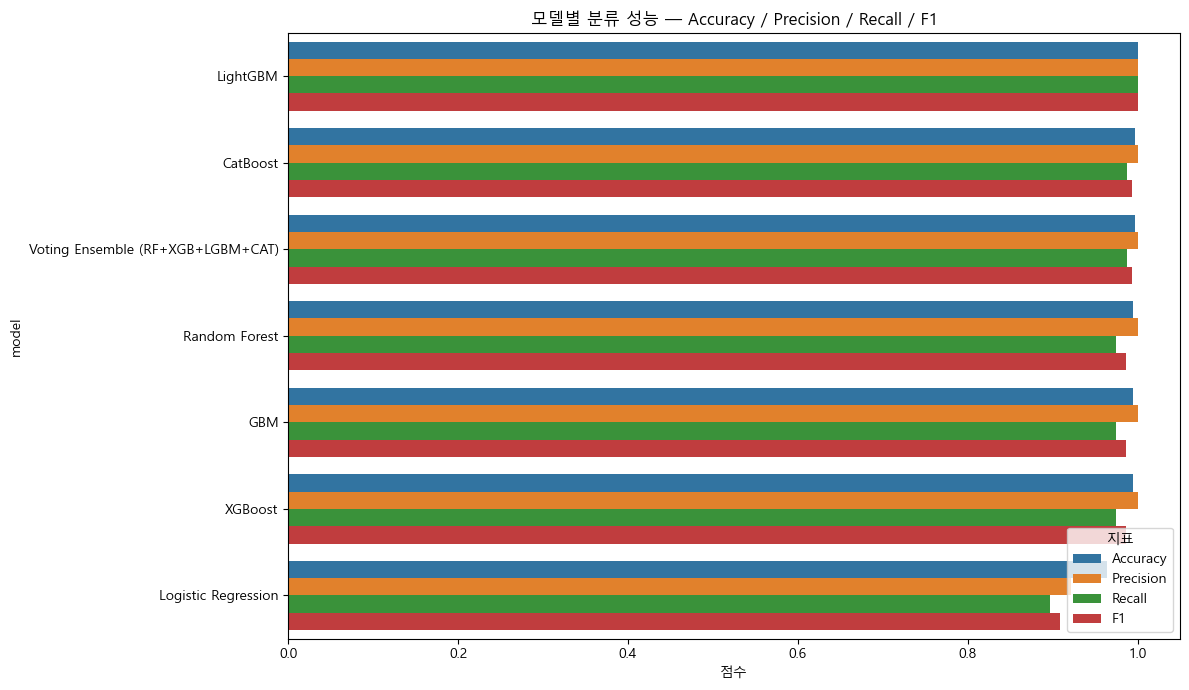

In [89]:
# 지표 4개를 한 그래프에
metrics_long = compare_cls_df.melt(
    id_vars='model',
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1'],
    var_name='지표', value_name='값'
)
metrics_long['type'] = metrics_long['model'].apply(
    lambda x: 'Ensemble' if 'Voting' in x else 'Single'
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=metrics_long, x='값', y='model', hue='지표',
    orient='h'
)
plt.title('모델별 분류 성능 — Accuracy / Precision / Recall / F1')
plt.xlabel('점수')
plt.tight_layout()
plt.show()

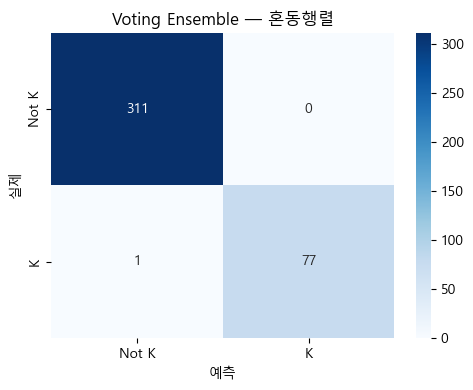

In [91]:
ens_pred = next(
    r['pred'] for r in results_cls
    if 'Voting' in r['model'] and 'Weighted' not in r['model']  # 기본 Voting
)

cm = confusion_matrix(y_test, ens_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not K', 'K'], yticklabels=['Not K', 'K'])
plt.title('Voting Ensemble — 혼동행렬')
plt.xlabel('예측')
plt.ylabel('실제')
plt.tight_layout()
plt.show()

---
## B-5) 모델 결과 분석 및 고도화

**[과제]** 써니는 클래스 불균형이 성능에 영향을 줄 수 있다고 생각했습니다. 다만 모델마다 불균형을 다루는 방식이 다르다는 것을 알게 되었습니다. AI와 함께 각 모델에 맞는 불균형 완화 방법을 적용하고 적용 전후 성능을 비교해 보세요.

> 예:Random Forest는 `class_weight`, GBM은 `sample_weight`, XGBoost는 `scale_pos_weight`, LightGBM은 `is_unbalance`, CatBoost는 `auto_class_weights`

**[과제]** 써니는 불균형 완화까지 적용한 5개 모델의 변수 중요도를 비교해서, K_Scatch 결함 여부에 공통적으로 큰 영향을 주는 변수가 무엇인지 확인하려고 합니다. AI와 상의해서 비교 시각화를 만들어 보세요.

**[과제]** 써니는 불균형 완화 이후 F1-score가 가장 좋았던 모델의 성능을 하이퍼파라미터 튜닝으로 더 끌어올리고 싶습니다. AI와 함께 적절한 탐색 범위를 설정하여 GridSearchCV로 성능을 개선해 보세요.